#  Sprint 1 : Fondations : État de l'Art, Environnement & Préparation des Données


---

**PFE :** Agentic GraphRAG pour le Raisonnement Complexe sur des Corpus Techniques  
**Étudiante :** Wiame Anejjar  
**Encadrant :** Pr. Abdelaaziz Hessane  
**Université :** Moulay Ismail — Faculté des Sciences de Meknès  
**Parcours :** Master SDIA 2025–2026  
**Date :** Avril–Mai 2026  

---

## Objectifs du notebook

- Collecte automatisée de 500 abstracts depuis arXiv (cs.AI)  
- Intégration du dataset HotpotQA pour l’évaluation du raisonnement multi-hop  
- Analyse exploratoire du corpus (tokens, thématiques) avec visualisations  
- Prétraitement et structuration des données (raw vs processed)  
- Initialisation de l’indexation GraphRAG avec LightRAG (extraction entités/relations)  
- Gestion des contraintes API (rate limits) avec mécanisme de checkpointing  
- Sauvegarde des index et bases vectorielles pour assurer la continuité  
---

>  **Note importante**  
> Utilisation uniquement les abstracts via l'API arXiv.  
> L'abstract contient toutes les entités clés pour construire le Knowledge Graph.

## Partie 1 : Structure Projet + Téléchargement Données + Statistiques + Visualisations

## 1 _ Installation des dépendances

Installation de toutes les bibliothèques nécessaires pour la Partie 1.

In [ ]:
# INSTALLATION DES DÉPENDANCES
import subprocess, sys

packages = [
    'arxiv',           # API arXiv officielle (abstracts sans PDF)
    'datasets',        # HuggingFace Datasets (HotpotQA)
    'matplotlib',      # Visualisations
    'seaborn',         # Visualisations avancées
    'pandas',          # Manipulation de données
    'numpy',           # Calculs numériques
    'tiktoken',        # Comptage de tokens (OpenAI tokenizer)
    'wordcloud',       # Nuage de mots
    'tqdm',            # Barres de progression
]

for pkg in packages:
    print(f'Installation de {pkg}...')
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

print('\n Toutes les dépendances sont installées !')

Installation de arxiv...
Installation de datasets...
Installation de matplotlib...
Installation de seaborn...
Installation de pandas...
Installation de numpy...
Installation de tiktoken...
Installation de wordcloud...
Installation de tqdm...

 Toutes les dépendances sont installées !


## 2 _Création de la structure de projet


In [ ]:
# CRÉATION DE LA STRUCTURE DE PROJET
import os
from pathlib import Path

# Racine du projet
PROJECT_ROOT = Path('agentic_graphrag')

# Tous les dossiers à créer
DIRS = [
    PROJECT_ROOT / 'data' / 'raw',          # JSONs bruts des APIs
    PROJECT_ROOT / 'data' / 'chunks',       # Texte découpé avec overlap
    PROJECT_ROOT / 'data' / 'processed',    # Triplets + checkpoints
    PROJECT_ROOT / 'indexes' / 'chroma_db', # Embeddings ChromaDB
    PROJECT_ROOT / 'indexes' / 'lightrag',  # Graphe LightRAG
    PROJECT_ROOT / 'neo4j_data',            # Volume Docker Neo4j
    PROJECT_ROOT / 'src',                   # Code source Python
    PROJECT_ROOT / 'notebooks',             # Jupyter notebooks
    PROJECT_ROOT / 'figures',               # Visualisations PNG
    PROJECT_ROOT / 'reports',               # Rapports générés
]

# Création de tous les dossiers
for d in DIRS:
    d.mkdir(parents=True, exist_ok=True)
    print(f' Créé : {d}')

print('\n Structure de projet créée avec succès !')
print(f' Racine du projet : {PROJECT_ROOT.absolute()}')

 Créé : agentic_graphrag\data\raw
 Créé : agentic_graphrag\data\chunks
 Créé : agentic_graphrag\data\processed
 Créé : agentic_graphrag\indexes\chroma_db
 Créé : agentic_graphrag\indexes\lightrag
 Créé : agentic_graphrag\neo4j_data
 Créé : agentic_graphrag\src
 Créé : agentic_graphrag\notebooks
 Créé : agentic_graphrag\figures
 Créé : agentic_graphrag\reports

 Structure de projet créée avec succès !
 Racine du projet : c:\Users\ADMIN\Desktop\PFE_GraphRag\agentic_graphrag


## 3 _ Téléchargement du corpus arXiv (abstracts uniquement)

On télécharge **500 abstracts arXiv CS.AI** via l'API officielle.  
**Aucun PDF téléchargé**.

In [ ]:
import arxiv
import json
import time
from tqdm import tqdm
from pathlib import Path

OUTPUT_FILE = Path("data/raw/arxiv_500.json")
OUTPUT_FILE.parent.mkdir(parents=True, exist_ok=True)

if OUTPUT_FILE.exists():
    print(" Fichier déjà existant — chargement depuis le cache...")
    with open(OUTPUT_FILE, "r", encoding="utf-8") as f:
        docs = json.load(f)
    print(f" {len(docs)} articles chargés depuis le cache")
else:
    print(" Téléchargement des abstracts arXiv CS.AI...")
    print(" Aucun PDF téléchargé — abstracts uniquement \n")
    client = arxiv.Client(
        page_size=100,
        delay_seconds=3,    # Respecter les limites de l'API
        num_retries=5
    )
    search = arxiv.Search(
        query="cat:cs.AI",  # Catégorie CS.AI exclusivement
        max_results=500,
        sort_by=arxiv.SortCriterion.SubmittedDate,
        sort_order=arxiv.SortOrder.Descending
    )
    docs = []
    for paper in tqdm(client.results(search), total=500, desc="Téléchargement arXiv"):
        # On extrait UNIQUEMENT les métadonnées + abstract
        doc = {
            "id": paper.entry_id.split("/")[-1],  # ex: '2401.12345'
            "title": paper.title.strip(),
            "abstract": paper.summary.strip(),     #  Texte principal
            "authors": [a.name for a in paper.authors[:5]],  # Max 5 auteurs
            "categories": paper.categories,
            "published": str(paper.published.date()),
            "updated": str(paper.updated.date()),
            "url": paper.entry_id,
            # Texte complet = title + abstract 
            "text": f"Title: {paper.title.strip()}\n\nAbstract: {paper.summary.strip()}"
        }
        docs.append(doc)
        if len(docs) >= 500:
            break
    with open(OUTPUT_FILE, "w", encoding="utf-8") as f:
        json.dump(docs, f, ensure_ascii=False, indent=2)
    print(f"\n {len(docs)} articles sauvegardés dans {OUTPUT_FILE}")
    print(" 0 PDF téléchargé — abstracts uniquement")

print("\n Exemple d'article téléchargé :")
print(f"  ID       : {docs[0]["id"]}")
print(f"  Titre    : {docs[0]["title"][:80]}...")
print(f"  Abstract : {docs[0]["abstract"][:150]}...")
print(f"  Auteurs  : {docs[0]["authors"]}")
print(f"  Catégor. : {docs[0]["categories"]}")



 Téléchargement des abstracts arXiv CS.AI...
 Aucun PDF téléchargé — abstracts uniquement 



Téléchargement arXiv:   0%|          | 0/500 [00:00<?, ?it/s]

Téléchargement arXiv: 100%|█████████▉| 499/500 [00:13<00:00, 35.80it/s]


 500 articles sauvegardés dans PFE_Agentic_Graphrag\data\raw\arxiv_500.json
 0 PDF téléchargé — abstracts uniquement

 Exemple d'article téléchargé :
  ID       : 2604.24758v1
  Titre    : Personalized Worked Example Generation from Student Code Submissions using Patte...
  Abstract : Adaptive programming practice often relies on fixed libraries of worked examples and practice problems, which require substantial authoring effort and...
  Auteurs  : ['Griffin Pitts', 'Muntasir Hoq', 'Peter Brusilovsky', 'Narges Norouzi', 'Arto Hellas']
  Catégor. : ['cs.HC', 'cs.AI', 'cs.CY', 'cs.ET', 'cs.LG']


## 4 — Chargement du benchmark HotpotQA

HotpotQA est le benchmark de référence pour évaluer le raisonnement multi-sauts.  
On charge le **split validation complet (7405 questions)** via HuggingFace.

In [ ]:
# CHARGEMENT DU BENCHMARK HOTPOTQA Via HuggingFace Datasets 
# Split validation = 7405 questions multi-sauts

from datasets import load_dataset
import json
from pathlib import Path

OUTPUT_HOTPOT = Path('data/raw/hotpotqa_validation.json')
OUTPUT_HOTPOT.parent.mkdir(parents=True, exist_ok=True)


if OUTPUT_HOTPOT.exists():
    print(' HotpotQA déjà chargé — chargement depuis le cache...')
    with open(OUTPUT_HOTPOT, 'r', encoding='utf-8') as f:
        hotpot_data = json.load(f)
    print(f' {len(hotpot_data)} questions chargées depuis le cache')
else:
    print(' Chargement de HotpotQA depuis HuggingFace...')

    # Chargement du dataset complet
    dataset = load_dataset('hotpot_qa', 'distractor', split='validation')

    print(f' Dataset chargé : {len(dataset)} questions au total')

    # Conversion en liste de dicts
    hotpot_data = []
    for item in dataset:
        hotpot_data.append({
            'id': item['id'],
            'question': item['question'],
            'answer': item['answer'],
            'type': item['type'],
            'level': item['level'],
            'supporting_facts': item['supporting_facts'],
        })

    # Sauvegarde
    with open(OUTPUT_HOTPOT, 'w', encoding='utf-8') as f:
        json.dump(hotpot_data, f, ensure_ascii=False, indent=2)

    print(f' {len(hotpot_data)} questions sauvegardées dans {OUTPUT_HOTPOT}')

# Statistiques rapides
types = {}
levels = {}
for q in hotpot_data:
    types[q['type']] = types.get(q['type'], 0) + 1
    levels[q['level']] = levels.get(q['level'], 0) + 1

print('\n Statistiques HotpotQA :')
print(f'  Total questions     : {len(hotpot_data)}')
print(f'  Types               : {types}')
print(f'  Niveaux             : {levels}')
print(f'\n Exemple de question multi-sauts :')
print(f'  Q : {hotpot_data[0]["question"]}')
print(f'  R : {hotpot_data[0]["answer"]}')
print(f'  Type : {hotpot_data[0]["type"]} | Niveau : {hotpot_data[0]["level"]}')


 Chargement de HotpotQA depuis HuggingFace...
 Dataset chargé : 7405 questions au total
 7405 questions sauvegardées dans agentic_graphrag\data\raw\hotpotqa_validation.json

 Statistiques HotpotQA :
  Total questions     : 7405
  Types               : {'comparison': 1487, 'bridge': 5918}
  Niveaux             : {'hard': 7405}

 Exemple de question multi-sauts :
  Q : Were Scott Derrickson and Ed Wood of the same nationality?
  R : yes
  Type : comparison | Niveau : hard


## 5 — Statistiques descriptives du corpus arXiv

In [ ]:
# STATISTIQUES DESCRIPTIVES DU CORPUS ARXIV
# Tokénisation, distribution des thèmes, longueurs

import tiktoken
import numpy as np
import pandas as pd
from collections import Counter
import json
from pathlib import Path

# Tokenizer (cl100k_base = GPT-4 / Llama compatible)
tokenizer = tiktoken.get_encoding('cl100k_base')
OUTPUT_FILE = Path('data/raw/arxiv_500.json')

# Si 'docs' n'est pas défini, on le charge depuis le fichier JSON
if 'docs' not in locals():
    if OUTPUT_FILE.exists():
        print(' Chargement de "docs" depuis le fichier JSON...')
        with open(OUTPUT_FILE, 'r', encoding='utf-8') as f:
            docs = json.load(f)
        print(f' {len(docs)} articles chargés.')
    else:
        print(' Erreur : Le fichier arxiv_500.json n\'existe pas.')

print(" Calcul des statistiques descriptives du corpus arXiv...")
token_counts = []
word_counts = []
char_counts = []

for doc in docs:
    text = doc['abstract']
    token_counts.append(len(tokenizer.encode(text)))
    word_counts.append(len(text.split()))
    char_counts.append(len(text))

token_arr = np.array(token_counts)

print('=' * 55)
print('   STATISTIQUES CORPUS arXiv CS.AI')
print('=' * 55)
print(f'  Nombre de documents       : {len(docs)}')
print(f'  Tokens moyens/abstract    : {token_arr.mean():.0f}')
print(f'  Tokens médian/abstract    : {np.median(token_arr):.0f}')
print(f'  Tokens min/abstract       : {token_arr.min()}')
print(f'  Tokens max/abstract       : {token_arr.max()}')
print(f'  Total tokens corpus       : {token_arr.sum():,}')
print(f'  Mots moyens/abstract      : {np.mean(word_counts):.0f}')
print(f'  Caractères moyens/abstract: {np.mean(char_counts):.0f}')

# 2. Distribution des catégories arXiv 
all_cats = []
for doc in docs:
    all_cats.extend(doc['categories'])

top_cats = Counter(all_cats).most_common(15)

print('\n  Top 10 catégories arXiv :')
for cat, count in top_cats[:10]:
    print(f'    {cat:<15} : {count:>3} articles')

# 3. Distribution temporelle 
years = [doc['published'][:4] for doc in docs]
year_dist = Counter(years)

print('\n  Distribution par année :')
for year in sorted(year_dist.keys(), reverse=True)[:5]:
    print(f'    {year} : {year_dist[year]:>3} articles')

print('=' * 55)

# 4. Statistiques HotpotQA 
hotpot_q_lengths = [len(q['question'].split()) for q in hotpot_data]

print('\n  STATISTIQUES BENCHMARK HOTPOTQA')
print('=' * 55)
print(f'  Total questions           : {len(hotpot_data)}')
print(f'  Questions bridge (multi-sauts) : {types.get("comparison", 0) + types.get("bridge", 0) - types.get("comparison", 0)}')
print(f'  Questions comparison      : {types.get("comparison", 0)}')
print(f'  Questions bridge          : {types.get("bridge", 0)}')
print(f'  Longueur moy. question    : {np.mean(hotpot_q_lengths):.1f} mots')
print('=' * 55)

# 5. Sauvegarder les stats 
stats = {
    'arxiv': {
        'nb_documents': len(docs),
        'tokens_mean': float(token_arr.mean()),
        'tokens_median': float(np.median(token_arr)),
        'tokens_min': int(token_arr.min()),
        'tokens_max': int(token_arr.max()),
        'tokens_total': int(token_arr.sum()),
        'top_categories': dict(top_cats),
        'year_distribution': dict(year_dist),
    },
    'hotpotqa': {
        'nb_questions': len(hotpot_data),
        'types': types,
        'levels': levels,
        'question_length_mean': float(np.mean(hotpot_q_lengths)),
    }
}

import json
with open('data/raw/dataset_stats.json', 'w', encoding='utf-8') as f:
    json.dump(stats, f, ensure_ascii=False, indent=2)

print('\n Statistiques sauvegardées dans data/raw/dataset_stats.json')

 Chargement de "docs" depuis le fichier JSON...
 500 articles chargés.
 Calcul des statistiques descriptives du corpus arXiv...
   STATISTIQUES CORPUS arXiv CS.AI
  Nombre de documents       : 500
  Tokens moyens/abstract    : 258
  Tokens médian/abstract    : 259
  Tokens min/abstract       : 95
  Tokens max/abstract       : 497
  Total tokens corpus       : 129,038
  Mots moyens/abstract      : 187
  Caractères moyens/abstract: 1417

  Top 10 catégories arXiv :
    cs.AI           : 500 articles
    cs.LG           : 151 articles
    cs.CL           : 118 articles
    cs.CV           :  78 articles
    cs.CR           :  36 articles
    cs.SE           :  33 articles
    cs.IR           :  24 articles
    cs.MA           :  22 articles
    cs.HC           :  21 articles
    cs.CY           :  19 articles

  Distribution par année :
    2026 : 500 articles

  STATISTIQUES BENCHMARK HOTPOTQA
  Total questions           : 7405
  Questions bridge (multi-sauts) : 5918
  Questions comparis

## 6 — Visualisations 

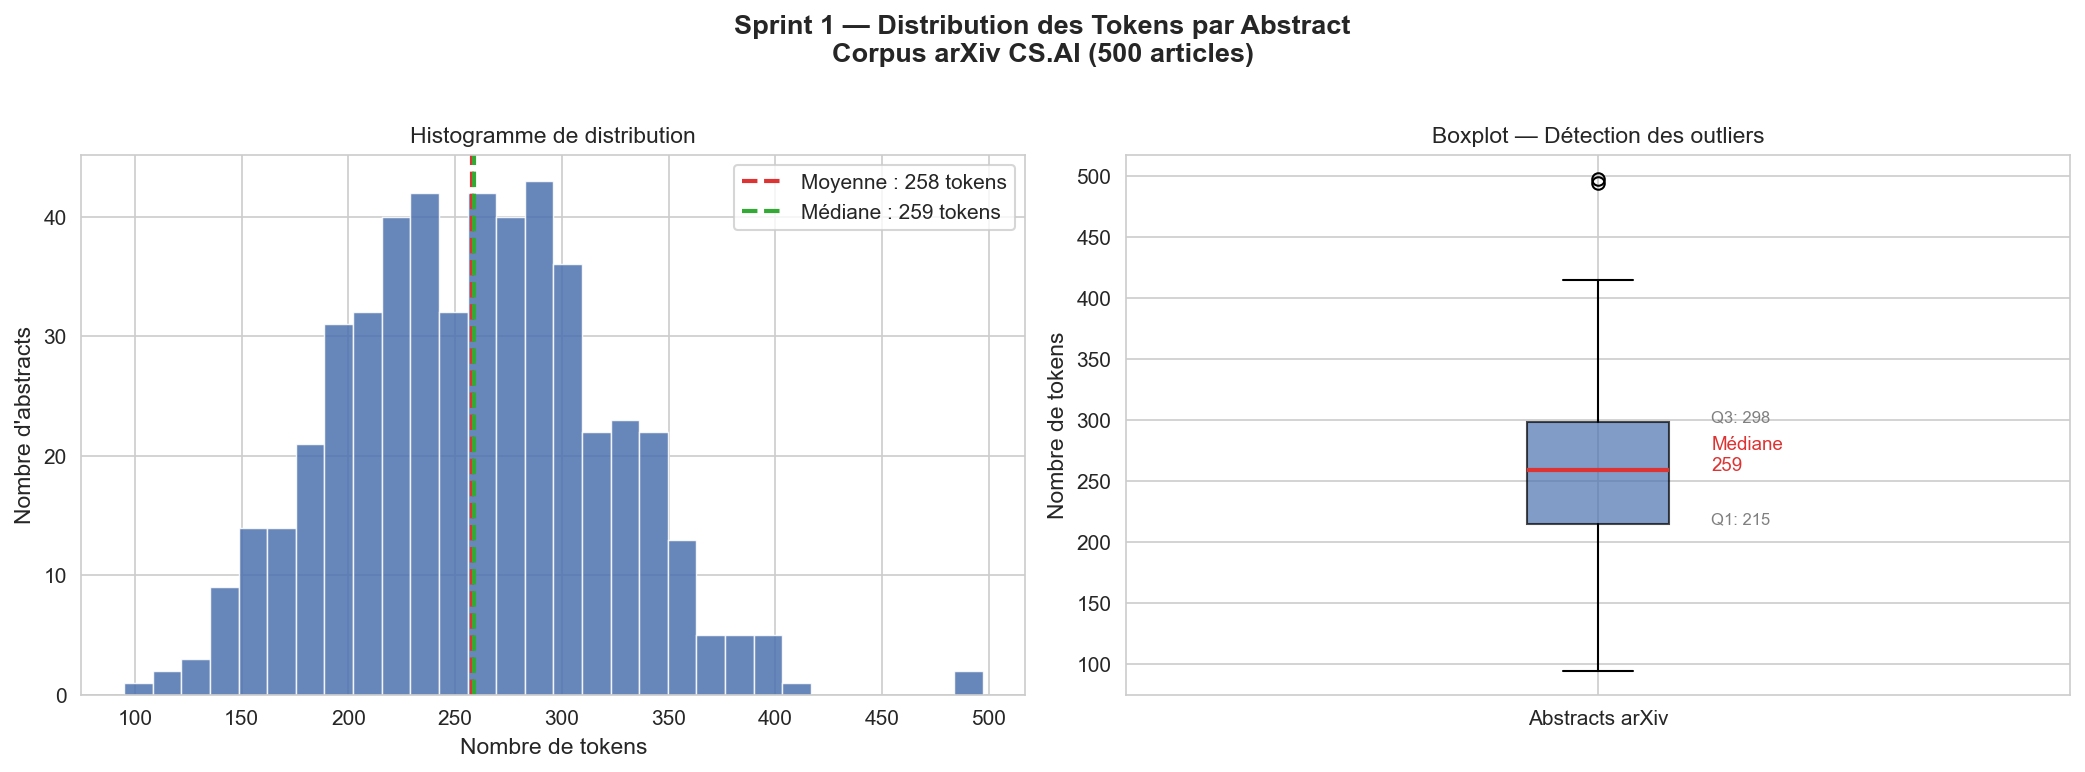

 Figure 1 sauvegardée dans le dossier : figures


In [ ]:
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import numpy as np
import tiktoken 
import json
from pathlib import Path

# 1. CHARGEMENT ET CALCUL 
OUTPUT_FILE = Path('data/raw/arxiv_500.json')
FIGURES_DIR = Path('figures')
FIGURES_DIR.mkdir(exist_ok=True)

with open(OUTPUT_FILE, 'r', encoding='utf-8') as f:
    docs = json.load(f)

# Initialisation du tokenizer 
tokenizer = tiktoken.get_encoding("cl100k_base")

token_counts = []
for doc in docs:
    token_counts.append(len(tokenizer.encode(doc['abstract'])))

# 2. VISUALISATION 
matplotlib.rcParams['font.family'] = 'DejaVu Sans'
matplotlib.rcParams['figure.dpi'] = 150
sns.set_style('whitegrid')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Sprint 1 — Distribution des Tokens par Abstract\nCorpus arXiv CS.AI (500 articles)',
             fontsize=13, fontweight='bold', y=1.02)

# Histogramme
ax1 = axes[0]
n, bins, patches = ax1.hist(token_counts, bins=30,
                             color='#4C72B0', edgecolor='white', linewidth=0.7, alpha=0.85)
ax1.axvline(np.mean(token_counts), color='#DD3333', linestyle='--', linewidth=2,
            label=f'Moyenne : {np.mean(token_counts):.0f} tokens')
ax1.axvline(np.median(token_counts), color='#33AA33', linestyle='--', linewidth=2,
            label=f'Médiane : {np.median(token_counts):.0f} tokens')
ax1.set_xlabel('Nombre de tokens', fontsize=11)
ax1.set_ylabel('Nombre d\'abstracts', fontsize=11)
ax1.set_title('Histogramme de distribution', fontsize=11)
ax1.legend(fontsize=10)

# Boxplot
ax2 = axes[1]
bp = ax2.boxplot(token_counts, vert=True, patch_artist=True,
                 boxprops=dict(facecolor='#4C72B0', alpha=0.7),
                 medianprops=dict(color='#DD3333', linewidth=2))
ax2.set_ylabel('Nombre de tokens', fontsize=11)
ax2.set_title('Boxplot — Détection des outliers', fontsize=11)
ax2.set_xticks([1])
ax2.set_xticklabels(['Abstracts arXiv'])

# Annotation des quartiles
q1, q3 = np.percentile(token_counts, [25, 75])
ax2.text(1.12, np.median(token_counts), f'Médiane\n{np.median(token_counts):.0f}',
         fontsize=9, color='#DD3333')
ax2.text(1.12, q1, f'Q1: {q1:.0f}', fontsize=8, color='gray')
ax2.text(1.12, q3, f'Q3: {q3:.0f}', fontsize=8, color='gray')

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/fig1_distribution_tokens.png', dpi=150, bbox_inches='tight')
plt.show()
print(f' Figure 1 sauvegardée dans le dossier : {FIGURES_DIR}')


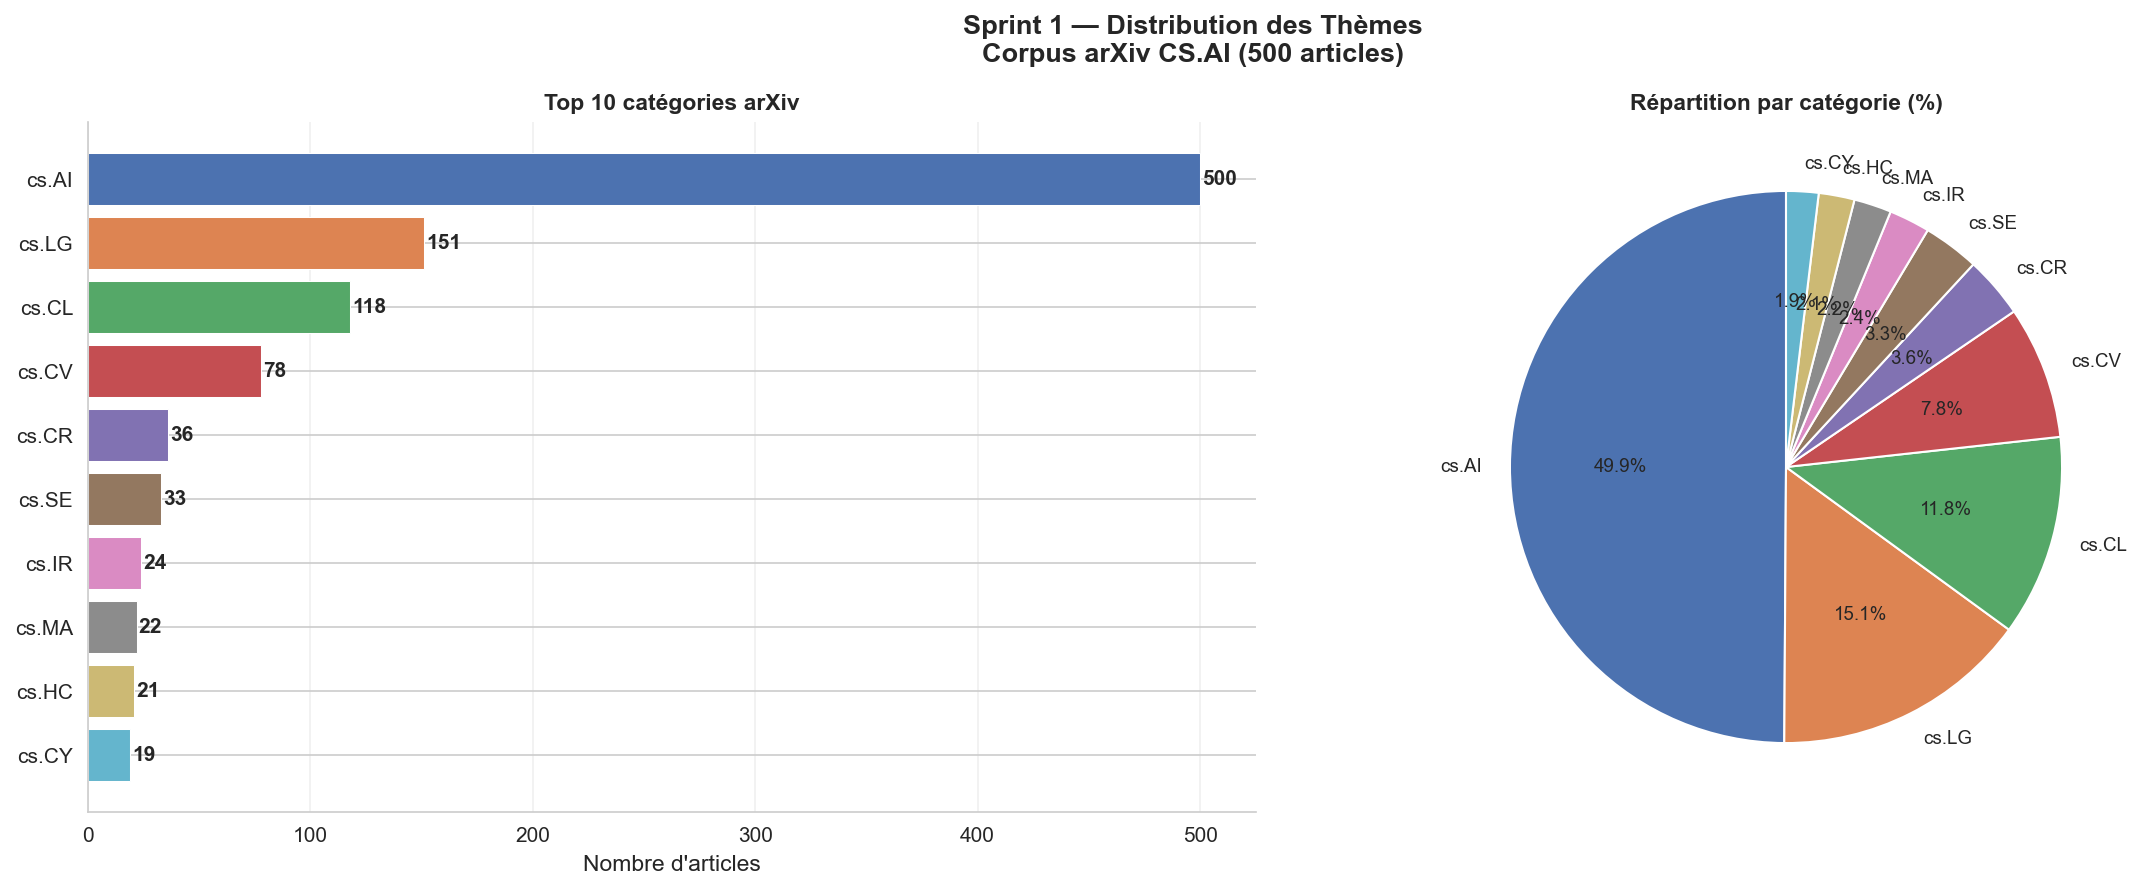

 Figure 2 sauvegardée : figures/fig2_distribution_themes.png


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import json
from pathlib import Path

# 1. CALCUL DES CATÉGORIES 
OUTPUT_FILE = Path('data/raw/arxiv_500.json')
FIGURES_DIR = Path('figures')
FIGURES_DIR.mkdir(exist_ok=True)

# Chargement des données
with open(OUTPUT_FILE, 'r', encoding='utf-8') as f:
    docs = json.load(f)

# Extraction et comptage des catégories
all_categories = []
for doc in docs:
    all_categories.extend(doc['categories'])

top_cats = Counter(all_categories).most_common()

# 2. VISUALISATION 
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Sprint 1 — Distribution des Thèmes\nCorpus arXiv CS.AI (500 articles)',
             fontsize=13, fontweight='bold')

cats_labels = [c[0] for c in top_cats[:10]]
cats_values = [c[1] for c in top_cats[:10]]

colors_palette = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2',
                  '#937860', '#DA8BC3', '#8C8C8C', '#CCB974', '#64B5CD']

# Barres horizontales
ax1 = axes[0]
bars = ax1.barh(cats_labels[::-1], cats_values[::-1],
                color=colors_palette[::-1], edgecolor='white', linewidth=0.5)
ax1.set_xlabel('Nombre d\'articles', fontsize=11)
ax1.set_title('Top 10 catégories arXiv', fontsize=11, fontweight='bold')
for bar, val in zip(bars, cats_values[::-1]):
    ax1.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
             str(val), va='center', fontsize=10, fontweight='bold')
ax1.grid(axis='x', alpha=0.3)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# Camembert
ax2 = axes[1]
wedges, texts, autotexts = ax2.pie(
    cats_values, labels=cats_labels,
    colors=colors_palette,
    autopct='%1.1f%%', startangle=90,
    textprops={'fontsize': 9}
)
ax2.set_title('Répartition par catégorie (%)', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/fig2_distribution_themes.png', dpi=150, bbox_inches='tight')
plt.show()
print(f' Figure 2 sauvegardée : {FIGURES_DIR}/fig2_distribution_themes.png')


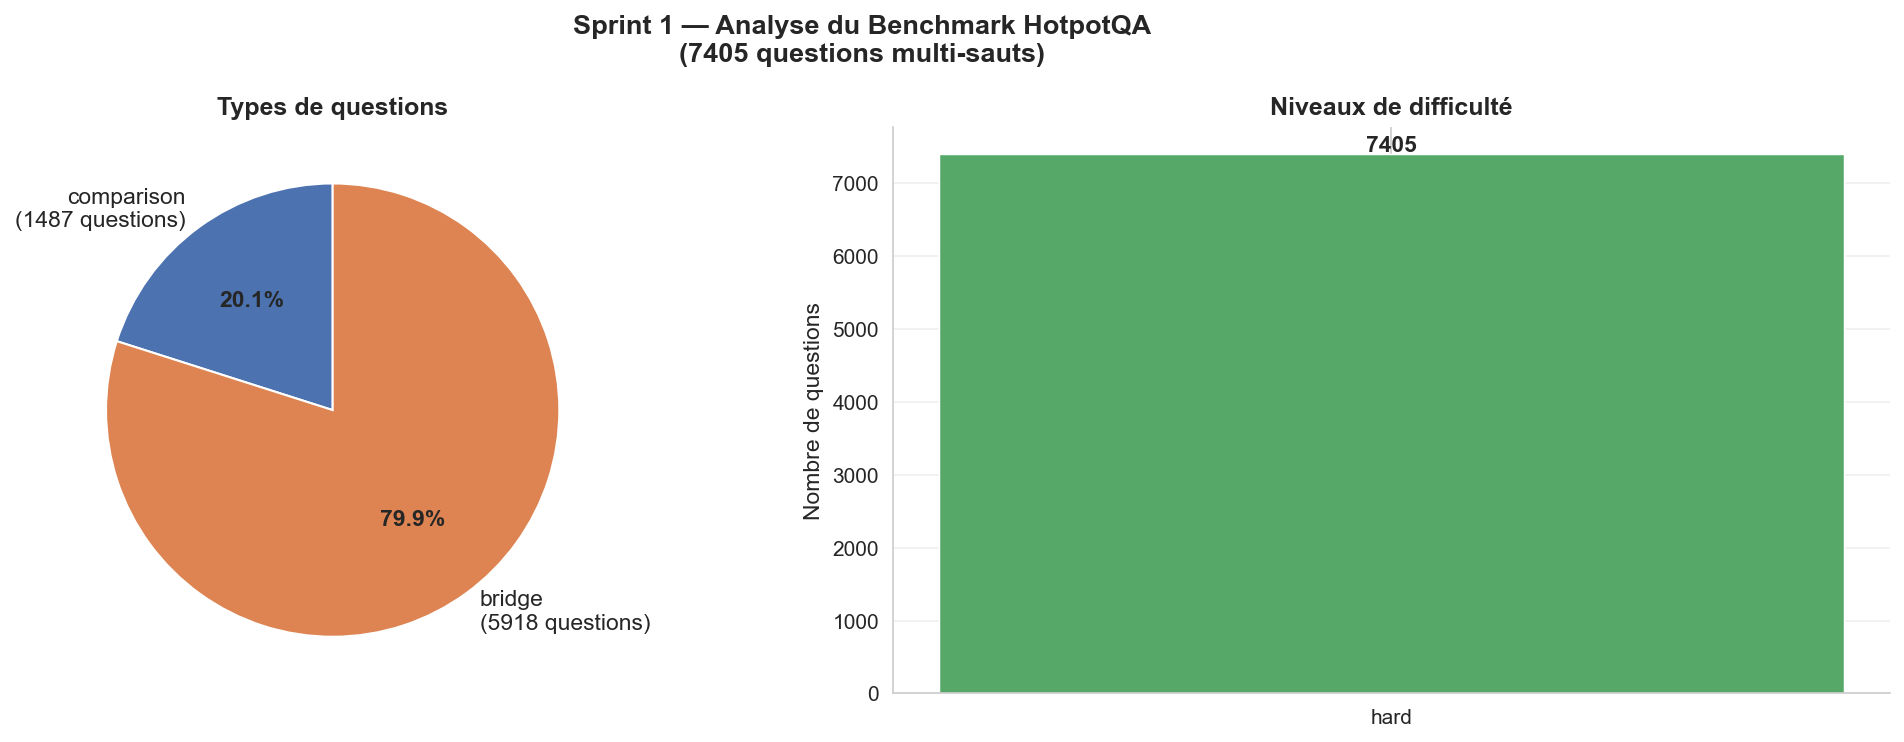

 Figure 3 sauvegardée : figures/fig3_hotpotqa_analyse.png


In [ ]:
# HotpotQA — Types et niveaux de questions

import matplotlib.pyplot as plt
import json
from pathlib import Path

#  CHARGEMENT DES DONNÉES HOTPOTQA
OUTPUT_HOTPOT = Path('data/raw/hotpotqa_validation.json')
FIGURES_DIR = Path('figures')
FIGURES_DIR.mkdir(exist_ok=True)

if not OUTPUT_HOTPOT.exists():
    print("Erreur : Le fichier HotpotQA n'existe pas.")
else:
    with open(OUTPUT_HOTPOT, 'r', encoding='utf-8') as f:
        hotpot_data = json.load(f)

    # Calcul des variables 'types' et 'levels' nécessaires pour le graphique
    types = {}
    levels = {}
    for q in hotpot_data:
        types[q['type']] = types.get(q['type'], 0) + 1
        levels[q['level']] = levels.get(q['level'], 0) + 1

    # VISUALISATION 
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('Sprint 1 — Analyse du Benchmark HotpotQA\n(7405 questions multi-sauts)',
                 fontsize=13, fontweight='bold')

    # Types de questions
    ax1 = axes[0]
    type_labels = list(types.keys())
    type_values = list(types.values())
    type_colors = ['#4C72B0', '#DD8452']

    wedges, texts, autotexts = ax1.pie(
        type_values,
        labels=[f"{l}\n({v} questions)" for l, v in zip(type_labels, type_values)],
        colors=type_colors,
        autopct='%1.1f%%',
        startangle=90,
        textprops={'fontsize': 11}
    )
    for at in autotexts:
        at.set_fontweight('bold')
    ax1.set_title('Types de questions', fontsize=12, fontweight='bold')

    # Niveaux de difficulté
    ax2 = axes[1]
    level_labels = list(levels.keys())
    level_values = list(levels.values())
    level_colors = ['#55A868', '#DD8452', '#C44E52']

    bars = ax2.bar(level_labels, level_values,
                   color=level_colors[:len(level_labels)],
                   edgecolor='white', linewidth=0.7)
    ax2.set_ylabel('Nombre de questions', fontsize=11)
    ax2.set_title('Niveaux de difficulté', fontsize=12, fontweight='bold')
    for bar, val in zip(bars, level_values):
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                 str(val), ha='center', fontsize=11, fontweight='bold')
    ax2.grid(axis='y', alpha=0.3)
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)

    plt.tight_layout()
    plt.savefig(f'{FIGURES_DIR}/fig3_hotpotqa_analyse.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f' Figure 3 sauvegardée : {FIGURES_DIR}/fig3_hotpotqa_analyse.png')


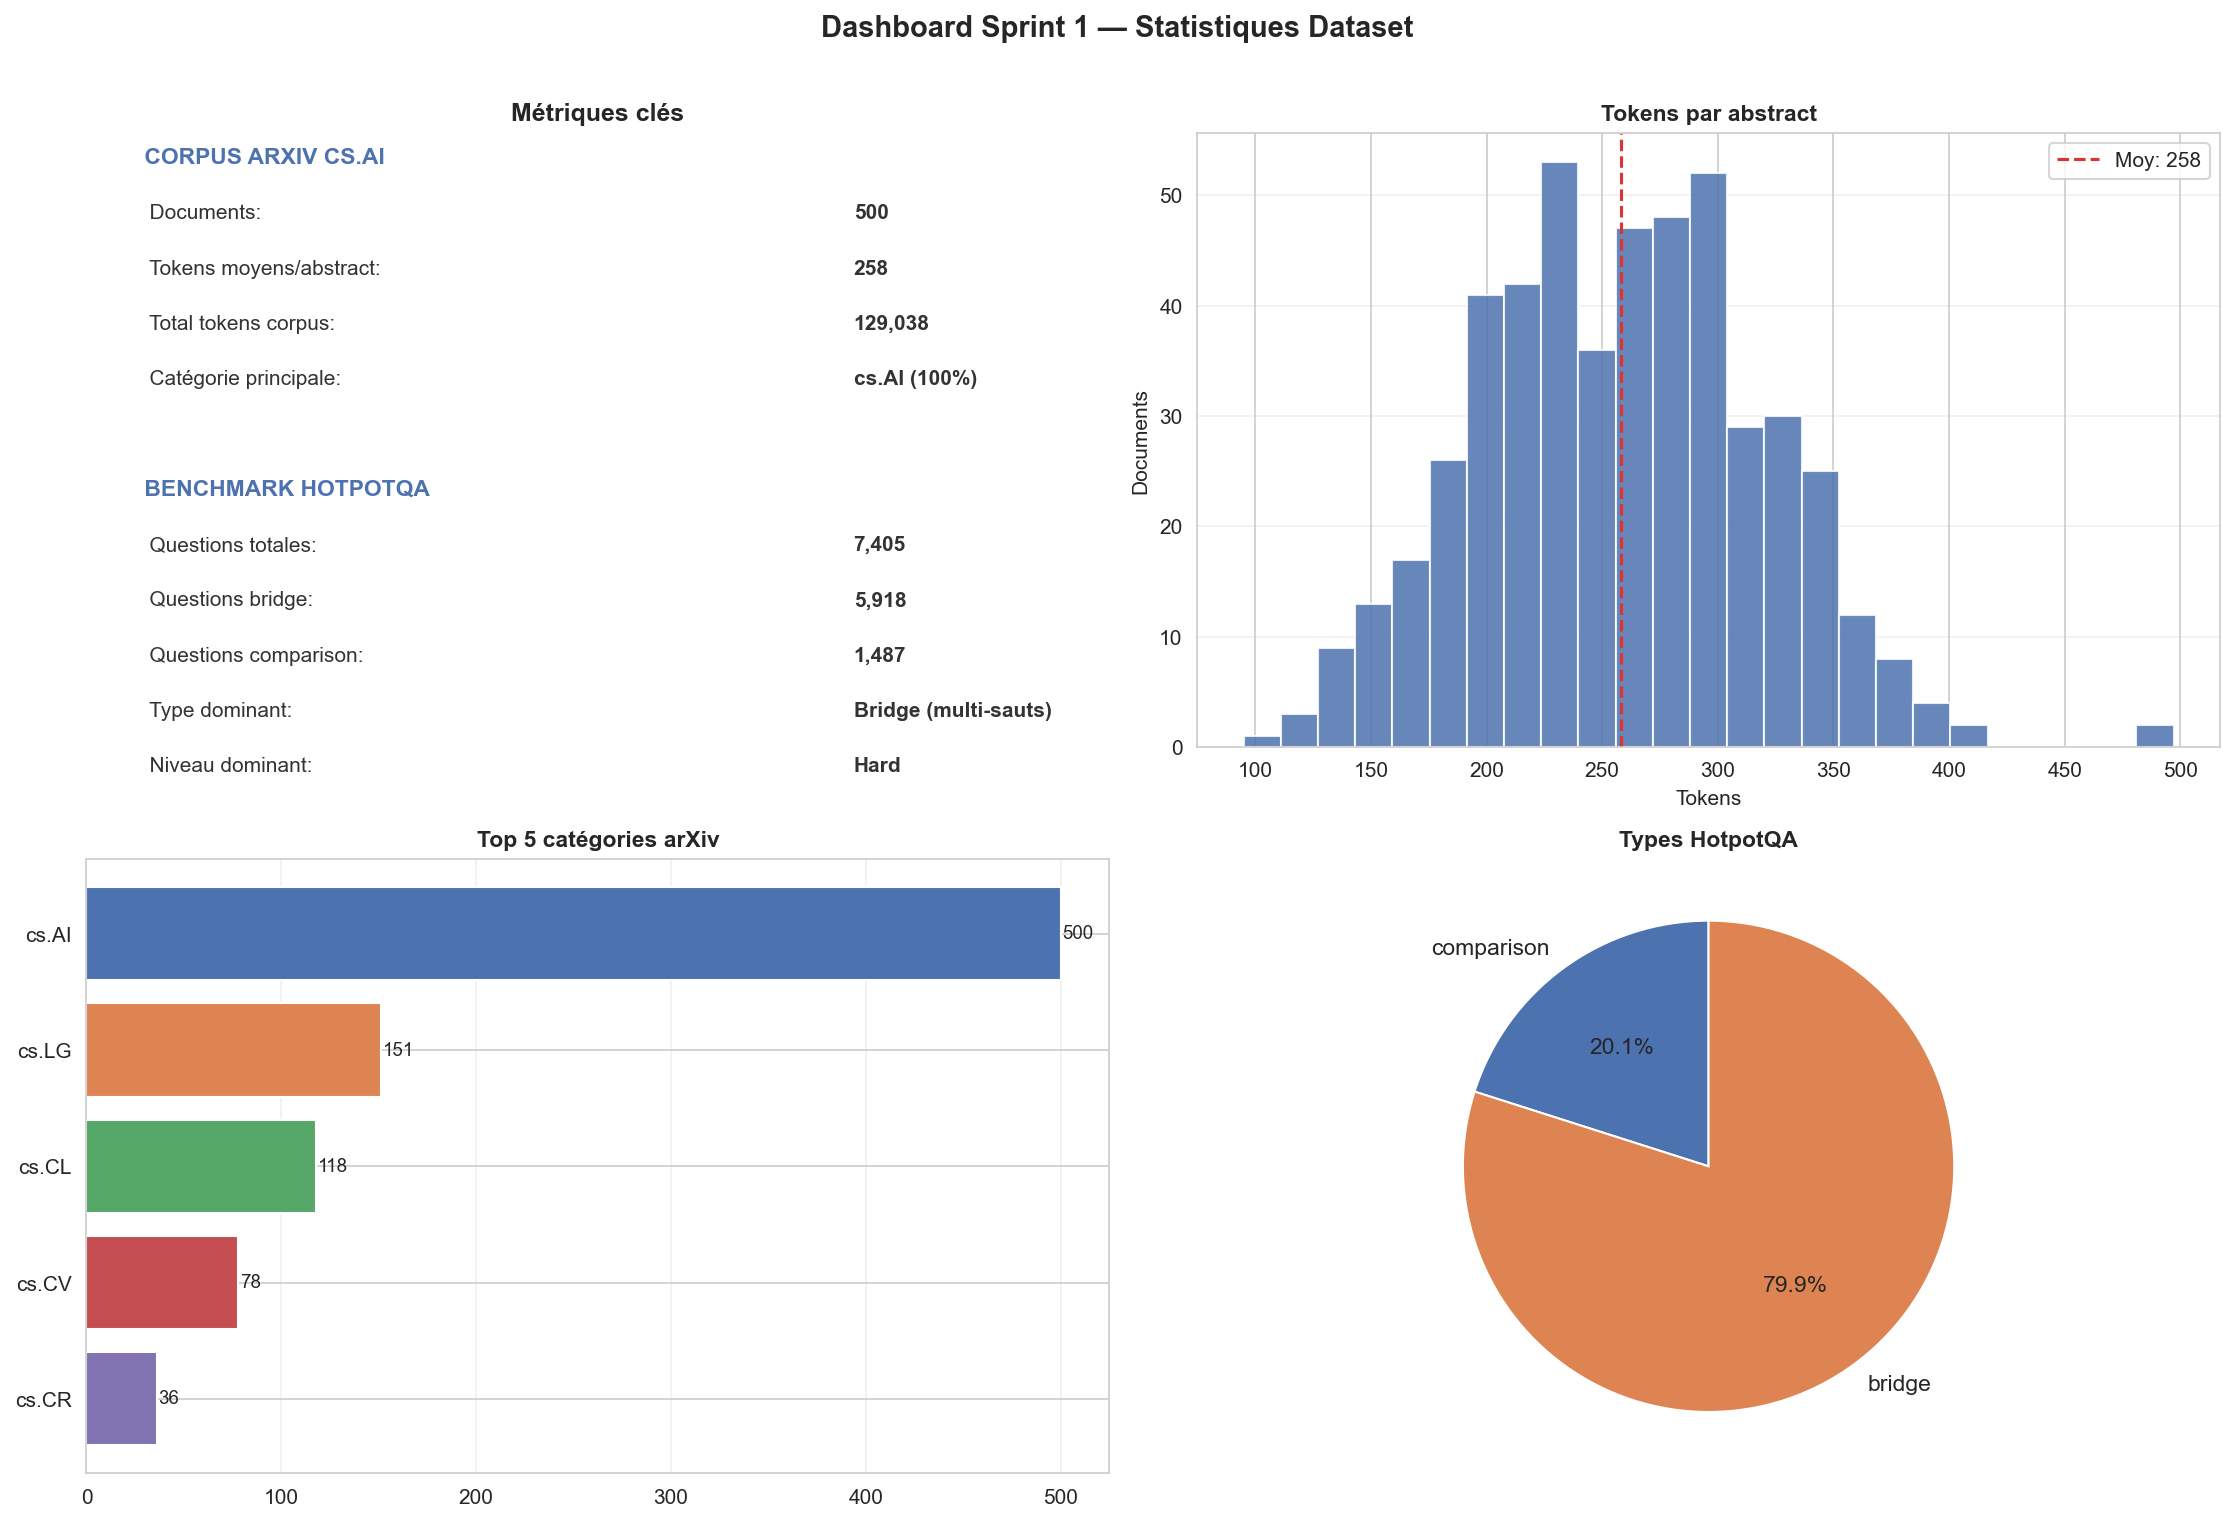

 Figure 4 (Dashboard) sauvegardée : fig4_dashboard_complet.png


In [ ]:
# Distribution temporelle du corpus + Dashboard complet

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Dashboard Sprint 1 — Statistiques Dataset',
             fontsize=14, fontweight='bold', y=1.01)

#  Panel 1 : Métriques clés (texte) 
ax00 = axes[0, 0]
ax00.axis('off')

token_arr = np.array(token_counts)

# Définition des métriques pour le tableau
metrics = [
    (' CORPUS ARXIV CS.AI', None),
    ('Documents', f'{len(docs)}'),
    ('Tokens moyens/abstract', f'{np.mean(token_counts):.0f}'),
    ('Total tokens corpus', f'{int(token_arr.sum()):,}'), 
    ('Catégorie principale', 'cs.AI (100%)'),
    ('', None),
    (' BENCHMARK HOTPOTQA', None),
    ('Questions totales', f'{len(hotpot_data):,}'),
    ('Questions bridge', f'{types.get("bridge", 0):,}'),
    ('Questions comparison', f'{types.get("comparison", 0):,}'),
    ('Type dominant', 'Bridge (multi-sauts)'),
    ('Niveau dominant', 'Hard'),
   
]

y_pos = 0.95
for label, value in metrics:
    if value is None:
        ax00.text(0.05, y_pos, label, fontsize=11, fontweight='bold',
                  color='#4C72B0', transform=ax00.transAxes)
    else:
        ax00.text(0.05, y_pos, f'  {label}:', fontsize=10,
                  transform=ax00.transAxes, color='#333333')
        ax00.text(0.75, y_pos, value, fontsize=10, fontweight='bold',
                  transform=ax00.transAxes, color='#333333')
    y_pos -= 0.09
ax00.set_title('Métriques clés', fontsize=12, fontweight='bold')

#  Panel 2 : Distribution tokens 
ax01 = axes[0, 1]
ax01.hist(token_counts, bins=25, color='#4C72B0', edgecolor='white', alpha=0.85)
ax01.axvline(np.mean(token_counts), color='#DD3333', linestyle='--', linewidth=1.5,
             label=f'Moy: {np.mean(token_counts):.0f}')
ax01.set_title('Tokens par abstract', fontsize=11, fontweight='bold')
ax01.set_xlabel('Tokens')
ax01.set_ylabel('Documents')
ax01.legend()
ax01.grid(axis='y', alpha=0.3)

#  Panel 3 : Top 5 catégories 
ax10 = axes[1, 0]
top5_labels = [c[0] for c in top_cats[:5]]
top5_values = [c[1] for c in top_cats[:5]]
bars = ax10.barh(top5_labels[::-1], top5_values[::-1],
                 color=colors_palette[:5][::-1], edgecolor='white')
for bar, val in zip(bars, top5_values[::-1]):
    ax10.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
              str(val), va='center', fontsize=9)
ax10.set_title('Top 5 catégories arXiv', fontsize=11, fontweight='bold')
ax10.grid(axis='x', alpha=0.3)

#  Panel 4 : Types HotpotQA 
ax11 = axes[1, 1]
ax11.pie(type_values, labels=type_labels,
         colors=['#4C72B0', '#DD8452'],
         autopct='%1.1f%%', startangle=90,
         textprops={'fontsize': 11})
ax11.set_title('Types HotpotQA', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/fig4_dashboard_complet.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Figure 4 (Dashboard) sauvegardée : fig4_dashboard_complet.png')

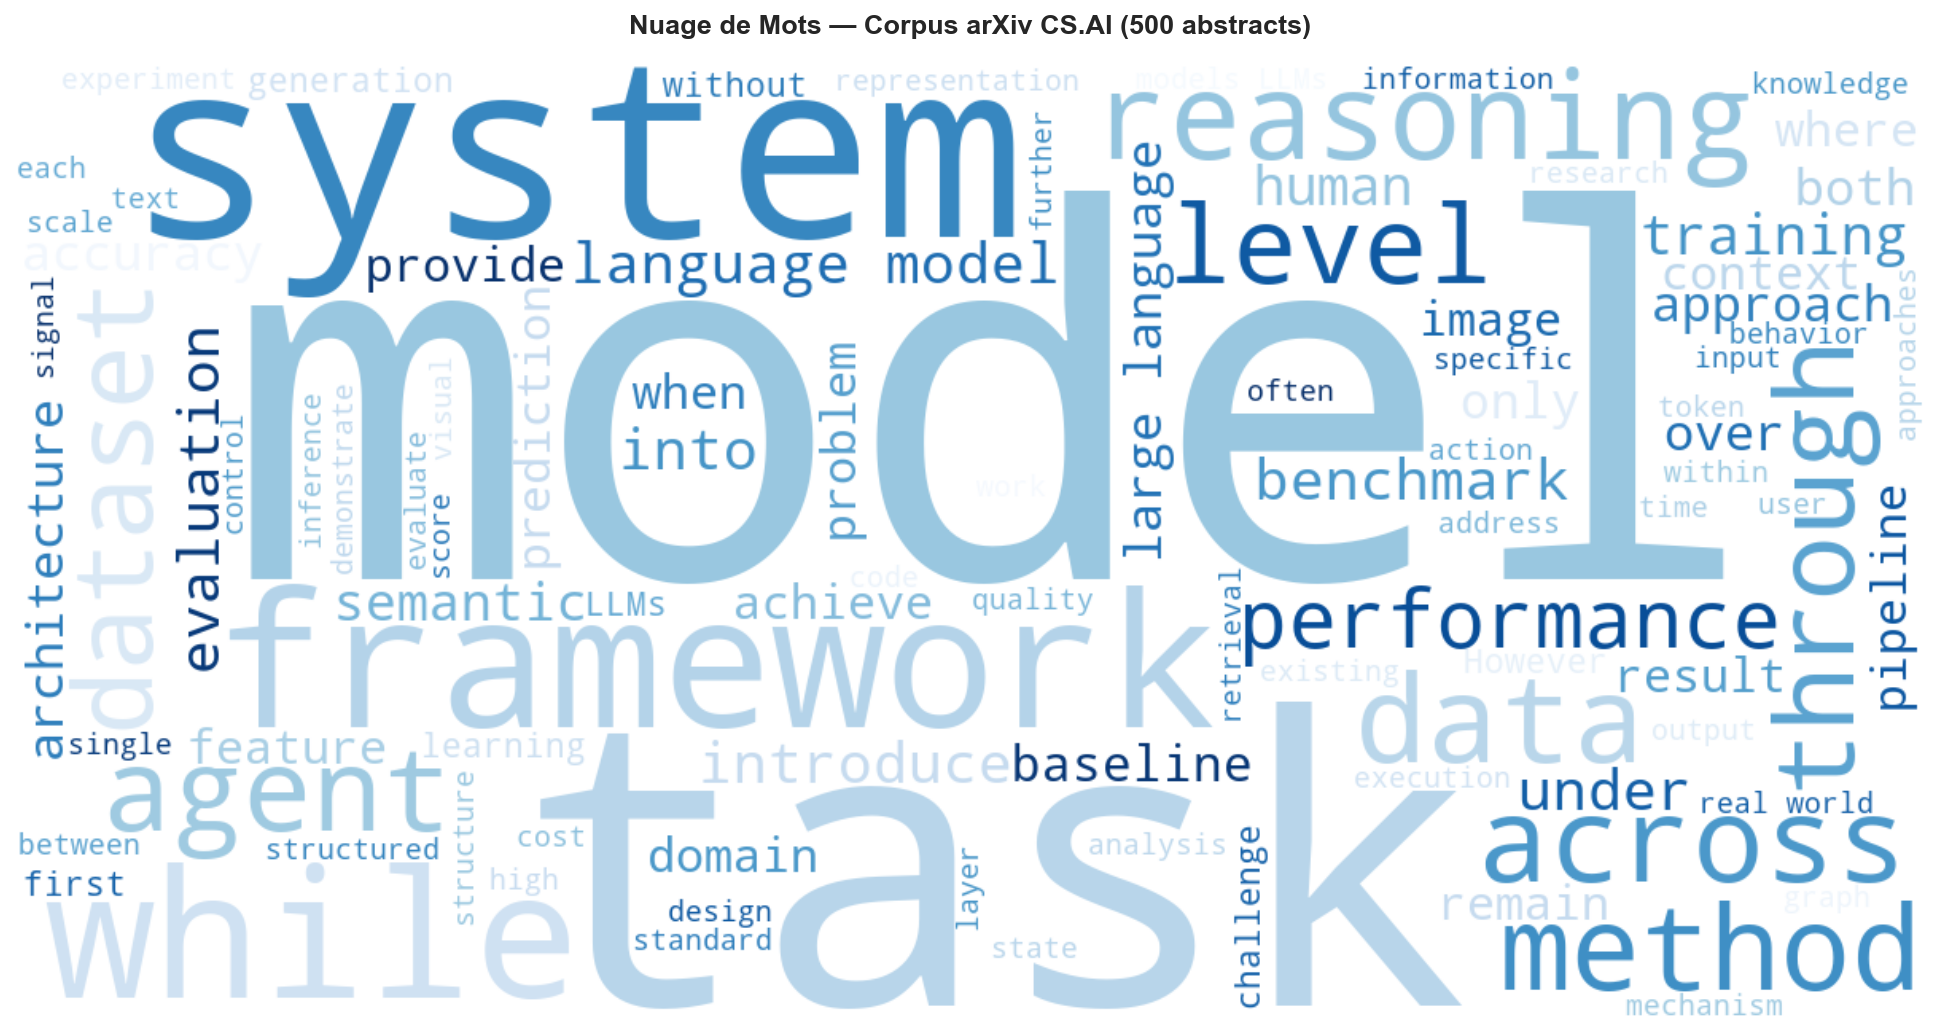

 Figure 5 (Nuage de mots) sauvegardée : fig5_wordcloud.png


In [ ]:
# Nuage de mots des abstracts

from wordcloud import WordCloud
import re

# Concaténer tous les abstracts
all_text = ' '.join([doc['abstract'] for doc in docs])

# Mots à exclure (stop words)
stopwords = {
    'the', 'a', 'an', 'and', 'or', 'in', 'of', 'to', 'is', 'are',
    'we', 'our', 'this', 'that', 'it', 'for', 'on', 'with', 'by',
    'as', 'be', 'can', 'at', 'from', 'which', 'has', 'have', 'been',
    'also', 'such', 'these', 'their', 'its', 'not', 'show', 'than',
    'more', 'based', 'paper', 'proposed', 'using', 'used', 'propose',
    'present', 'two', 'three', 'one', 'new', 'show', 'shown'
}

wc = WordCloud(
    width=1200, height=600,
    background_color='white',
    colormap='Blues',
    max_words=100,
    stopwords=stopwords,
    min_word_length=4,
    prefer_horizontal=0.9
).generate(all_text)

fig, ax = plt.subplots(figsize=(14, 7))
ax.imshow(wc, interpolation='bilinear')
ax.axis('off')
ax.set_title('Nuage de Mots — Corpus arXiv CS.AI (500 abstracts)',
             fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/fig5_wordcloud.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Figure 5 (Nuage de mots) sauvegardée : fig5_wordcloud.png')

## 7 — Récapitulatif et vérification finale

In [ ]:
# Vérification de tous les fichiers créés

import os
from pathlib import Path

print('  RÉCAPITULATIF — SPRINT 1 PARTIE 1')
print('  Wiame Anejjar | Master SDIA | Agentic GraphRAG')

# Vérification des fichiers créés
files_to_check = [
    ('data/raw/arxiv_500.json',       'Corpus arXiv (500 abstracts)'),
    ('data/raw/hotpotqa_validation.json', 'Benchmark HotpotQA (7405 questions)'),
    ('data/raw/dataset_stats.json',   'Statistiques descriptives'),
    ('figures/fig1_distribution_tokens.png',  'Figure 1 — Distribution tokens'),
    ('figures/fig2_distribution_themes.png',  'Figure 2 — Thèmes arXiv'),
    ('figures/fig3_hotpotqa_analyse.png',     'Figure 3 — HotpotQA'),
    ('figures/fig4_dashboard_complet.png',    'Figure 4 — Dashboard'),
    ('figures/fig5_wordcloud.png',            'Figure 5 — Nuage de mots'),
    ('JOURNAL.md',                    'Journal de bord'),
    ('.gitignore',                                     '.gitignore'),
    ('requirements.txt',                               'requirements.txt'),
]

print('\n Fichiers créés :')
all_ok = True
for filepath, description in files_to_check:
    path = Path(filepath)
    if path.exists():
        size = path.stat().st_size
        if size > 1024*1024:
            size_str = f'{size/1024/1024:.1f} Mo'
        elif size > 1024:
            size_str = f'{size/1024:.1f} Ko'
        else:
            size_str = f'{size} o'
        print(f'   {description:<42} ({size_str})')
    else:
        print(f'   MANQUANT : {description}')
        all_ok = False

print('\n Données téléchargées :')
print(f'  • Articles arXiv CS.AI     : {len(docs)} abstracts')
print(f'  • Questions HotpotQA       : {len(hotpot_data)} questions multi-sauts')
print(f'  • Tokens moyens/abstract   : {np.mean(token_counts):.0f} tokens')
print(f'  • Total tokens corpus      : {int(token_arr.sum()):,} tokens')

print('\n Prochaine étape : Partie 2 — Preprocessing + Chunking')

if all_ok:
    print('\n PARTIE 1 TERMINÉE AVEC SUCCÈS !')
else:
    print('\n  Certains fichiers sont manquants — relancer les cellules concernées')

print('=' * 60)

  RÉCAPITULATIF — SPRINT 1 PARTIE 1
  Wiame Anejjar | Master SDIA | Agentic GraphRAG

 Fichiers créés :
   Corpus arXiv (500 abstracts)               (1.6 Mo)
   Benchmark HotpotQA (7405 questions)        (3.1 Mo)
   Statistiques descriptives                  (788 o)
   Figure 1 — Distribution tokens             (84.1 Ko)
   Figure 2 — Thèmes arXiv                    (122.8 Ko)
   Figure 3 — HotpotQA                        (75.1 Ko)
   Figure 4 — Dashboard                       (158.4 Ko)
   Figure 5 — Nuage de mots                   (629.0 Ko)
   Journal de bord                            (8.2 Ko)
   .gitignore                                 (482 o)
   requirements.txt                           (3.4 Ko)

 Données téléchargées :
  • Articles arXiv CS.AI     : 500 abstracts
  • Questions HotpotQA       : 7405 questions multi-sauts
  • Tokens moyens/abstract   : 258 tokens
  • Total tokens corpus      : 129,038 tokens

 Prochaine étape : Partie 2 — Preprocessing + Chunking

 PARTIE 1 TE


---

#  Parties 2 & 3 : Prétraitement, Chunking & Indexation LightRAG

---


### Ce que couvre cette partie

| Semaine | Tâche |
|---------|-------|
| Semaine 3 | Prétraitement du texte + Chunking avec overlap |
| Semaine 4 | Indexation LightRAG (naive + hybrid) + Export Neo4j |



---
# Partie 2 — Prétraitement & Chunking
---

## 1 — Installation des dépendances 

In [ ]:
# INSTALLATION DES DÉPENDANCES 

import subprocess, sys

packages = [
    'tiktoken',      # Tokenizer pour comptage précis
    'tqdm',          # Barres de progression
    'matplotlib',    # Visualisations
    'seaborn',       # Visualisations
    'numpy',         # Calculs
    'pandas',        # Tableaux
]

for pkg in packages:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

print(' Dépendances installées')

 Dépendances installées


## 2 — Chargement des données brutes

In [ ]:
# Chargement des 500 abstracts arXiv téléchargés en Partie 1

import json
from pathlib import Path

RAW_DIR      = Path('data/raw')
CHUNKS_DIR   = Path('data/chunks')
PROCESSED_DIR = Path('data/processed')
FIGURES_DIR  = Path('figures')

# Créer les dossiers s'ils n'existent pas
for d in [CHUNKS_DIR, PROCESSED_DIR, FIGURES_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# Chargement des abstracts
with open(RAW_DIR / 'arxiv_500.json', 'r', encoding='utf-8') as f:
    docs = json.load(f)

print(f' {len(docs)} abstracts chargés depuis data/raw/arxiv_500.json')
print(f'\n Exemple de document brut :')
print(f'  Titre    : {docs[0]["title"][:80]}')
print(f'  Abstract : {docs[0]["abstract"][:200]}...')
print(f'  Catégor. : {docs[0]["categories"]}')

 500 abstracts chargés depuis data/raw/arxiv_500.json

 Exemple de document brut :
  Titre    : Personalized Worked Example Generation from Student Code Submissions using Patte
  Abstract : Adaptive programming practice often relies on fixed libraries of worked examples and practice problems, which require substantial authoring effort and may not correspond well to the logical errors and...
  Catégor. : ['cs.HC', 'cs.AI', 'cs.CY', 'cs.ET', 'cs.LG']


## 3 — Pipeline de nettoyage du texte

On nettoie les abstracts pour supprimer le bruit : caractères spéciaux, URLs, espaces multiples, etc.

In [ ]:
# PIPELINE DE NETTOYAGE DU TEXTE 
# Traitement : texte brut -> texte propre

import re

def clean_text(text: str) -> str:
    """
    Nettoie un texte brut pour le préparer à l'indexation.
    
    Opérations :
    1. Supprime les URLs
    2. Supprime les emails
    3. Normalise les sauts de ligne
    4. Supprime les espaces multiples
    5. Supprime les caractères de contrôle
    6. Normalise les tirets et guillemets
    """
    # 1. Supprimer les URLs
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    
    # 2. Supprimer les emails
    text = re.sub(r'\S+@\S+\.\S+', '', text)
    
    # 3. Remplacer les sauts de ligne multiples par un espace
    text = re.sub(r'\n+', ' ', text)
    
    # 4. Supprimer les caractères de contrôle non imprimables
    text = re.sub(r'[\x00-\x08\x0b\x0c\x0e-\x1f\x7f]', '', text)
    
    # 5. Normaliser les tirets em/en → tiret simple
    text = text.replace('\u2013', '-').replace('\u2014', '-')
    
    # 6. Normaliser les guillemets typographiques
    text = text.replace('\u201c', '"').replace('\u201d', '"')
    text = text.replace('\u2018', "'").replace('\u2019', "'")
    
    # 7. Supprimer les espaces multiples
    text = re.sub(r'\s+', ' ', text)
    
    # 8. Supprimer les espaces en début et fin
    text = text.strip()
    
    return text


#  Application du nettoyage à tous les documents 
print(' Nettoyage des abstracts en cours...')

docs_cleaned = []
too_short = 0

for doc in docs:
    # Nettoyer le titre et l'abstract
    title_clean   = clean_text(doc['title'])
    abstract_clean = clean_text(doc['abstract'])
    
    # Filtrer les abstracts trop courts (< 50 mots = inutiles)
    if len(abstract_clean.split()) < 50:
        too_short += 1
        continue
    
    docs_cleaned.append({
        'id'         : doc['id'],
        'title'      : title_clean,
        'abstract'   : abstract_clean,
        'authors'    : doc['authors'],
        'categories' : doc['categories'],
        'published'  : doc['published'],
        'url'        : doc.get('url', ''),
        # Texte complet = titre + abstract nettoyés
        'text'       : f"Title: {title_clean}\n\nAbstract: {abstract_clean}",
        'word_count' : len(abstract_clean.split()),
    })

# Sauvegarde dans data/processed/
with open(PROCESSED_DIR / 'arxiv_cleaned.json', 'w', encoding='utf-8') as f:
    json.dump(docs_cleaned, f, ensure_ascii=False, indent=2)

print(f'\n Résultats du nettoyage :')
print(f'  Documents originaux     : {len(docs)}')
print(f'  Documents nettoyés      : {len(docs_cleaned)}')
print(f'  Documents trop courts   : {too_short}')
print(f'  Taux de rétention       : {len(docs_cleaned)/len(docs)*100:.1f}%')
print(f'  Sauvegardé dans         : data/processed/arxiv_cleaned.json')

#  Comparaison avant/après nettoyage
print(f'\n Comparaison avant/après nettoyage :')
ex = docs[0]
ex_clean = docs_cleaned[0]
print(f'  AVANT : "{ex["abstract"][:120]}"')
print(f'  APRÈS : "{ex_clean["abstract"][:120]}"')

 Nettoyage des abstracts en cours...

 Résultats du nettoyage :
  Documents originaux     : 500
  Documents nettoyés      : 500
  Documents trop courts   : 0
  Taux de rétention       : 100.0%
  Sauvegardé dans         : data/processed/arxiv_cleaned.json

 Comparaison avant/après nettoyage :
  AVANT : "Adaptive programming practice often relies on fixed libraries of worked examples and practice problems, which require su"
  APRÈS : "Adaptive programming practice often relies on fixed libraries of worked examples and practice problems, which require su"


## 4 — Chunking avec overlap

Découpage du texte en chunks de **512 tokens** avec un **overlap de 50 tokens**.  
**Justification :** 512 tokens = compromis entre GraphRAG (600) et LightRAG (1200). Overlap 50 ≈ 10% standard RAG.

In [ ]:
# ============================================================
# CHUNKING AVEC OVERLAP 
# 
# Paramètres :
#   chunk_size  = 512 tokens  (compromis LightRAG/GraphRAG)
#   overlap     = 50 tokens   (10% du chunk = standard RAG)
# 
# Justification scientifique :
#   - GraphRAG Microsoft recommande 600 tokens/chunk
#   - LightRAG recommande 1200 tokens/chunk
#   - 512 = compromis optimal + limite max nomic-embed-text
#   - Overlap 50 évite de perdre le contexte aux frontières
# ============================================================

import tiktoken
import numpy as np
from tqdm import tqdm

# Tokenizer cl100k_base (compatible GPT-4 + Llama)
tokenizer = tiktoken.get_encoding('cl100k_base')

# Paramètres de chunking
CHUNK_SIZE = 512   # tokens par chunk
OVERLAP    = 50    # tokens de chevauchement entre chunks


def chunk_text(text: str, doc_id: str,
               chunk_size: int = CHUNK_SIZE,
               overlap: int = OVERLAP) -> list:
    """
    Découpe un texte en chunks de `chunk_size` tokens
    avec un overlap de `overlap` tokens.
    
    Le sliding window garantit qu'aucune information
    n'est perdue aux frontières entre chunks.
    """
    # Tokenisation du texte complet
    tokens = tokenizer.encode(text)
    
    chunks = []
    chunk_idx = 0
    start = 0
    
    while start < len(tokens):
        # Fin du chunk actuel
        end = min(start + chunk_size, len(tokens))
        
        # Tokens du chunk
        chunk_tokens = tokens[start:end]
        
        # Reconversion en texte
        chunk_text_decoded = tokenizer.decode(chunk_tokens)
        
        chunks.append({
            'chunk_id'    : f"{doc_id}_chunk_{chunk_idx}",
            'doc_id'      : doc_id,
            'text'        : chunk_text_decoded,
            'token_count' : len(chunk_tokens),
            'start_token' : start,
            'end_token'   : end,
            'chunk_index' : chunk_idx,
        })
        
        chunk_idx += 1
        
        # Avancer en tenant compte de l'overlap
        # start + chunk_size - overlap = sliding window
        start += (chunk_size - overlap)
        
        # Si le dernier chunk est trop petit (< 50 tokens), on l'ignore
        if len(tokens) - start < 50:
            break
    
    return chunks


#  Application du chunking à tous les documents 
print(f'  Chunking des {len(docs_cleaned)} documents...')
print(f'   Taille chunk : {CHUNK_SIZE} tokens')
print(f'   Overlap      : {OVERLAP} tokens ({OVERLAP/CHUNK_SIZE*100:.0f}%)')
print()

all_chunks = []
chunks_per_doc = []

for doc in tqdm(docs_cleaned, desc='Chunking'):
    # On chunke le texte complet (titre + abstract)
    doc_chunks = chunk_text(doc['text'], doc['id'])
    
    # Ajouter les métadonnées du document à chaque chunk
    for chunk in doc_chunks:
        chunk['title']      = doc['title']
        chunk['categories'] = doc['categories']
        chunk['published']  = doc['published']
    
    all_chunks.extend(doc_chunks)
    chunks_per_doc.append(len(doc_chunks))

# Sauvegarde des chunks
with open(CHUNKS_DIR / 'chunks_500.json', 'w', encoding='utf-8') as f:
    json.dump(all_chunks, f, ensure_ascii=False, indent=2)

# Statistiques
token_counts_chunks = [c['token_count'] for c in all_chunks]

print(f'\n Résultats du chunking :')
print(f'  Total chunks créés      : {len(all_chunks):,}')
print(f'  Chunks/document (moy.)  : {np.mean(chunks_per_doc):.1f}')
print(f'  Chunks/document (max)   : {max(chunks_per_doc)}')
print(f'  Tokens moyens/chunk     : {np.mean(token_counts_chunks):.0f}')
print(f'  Tokens min/chunk        : {min(token_counts_chunks)}')
print(f'  Tokens max/chunk        : {max(token_counts_chunks)}')
print(f'  Sauvegardé dans         : data/chunks/chunks_500.json')

print(f'\n Exemple de chunk :')
print(f'  chunk_id    : {all_chunks[0]["chunk_id"]}')
print(f'  doc_id      : {all_chunks[0]["doc_id"]}')
print(f'  token_count : {all_chunks[0]["token_count"]}')
print(f'  texte       : "{all_chunks[0]["text"][:150]}..."')

  Chunking des 500 documents...
   Taille chunk : 512 tokens
   Overlap      : 50 tokens (10%)



Chunking: 100%|██████████| 500/500 [00:00<00:00, 4032.36it/s]


 Résultats du chunking :
  Total chunks créés      : 501
  Chunks/document (moy.)  : 1.0
  Chunks/document (max)   : 2
  Tokens moyens/chunk     : 277
  Tokens min/chunk        : 60
  Tokens max/chunk        : 512
  Sauvegardé dans         : data/chunks/chunks_500.json

 Exemple de chunk :
  chunk_id    : 2604.24758v1_chunk_0
  doc_id      : 2604.24758v1
  token_count : 220
  texte       : "Title: Personalized Worked Example Generation from Student Code Submissions using Pattern-based Knowledge Components

Abstract: Adaptive programming p..."


## 5 — Visualisation du chunking

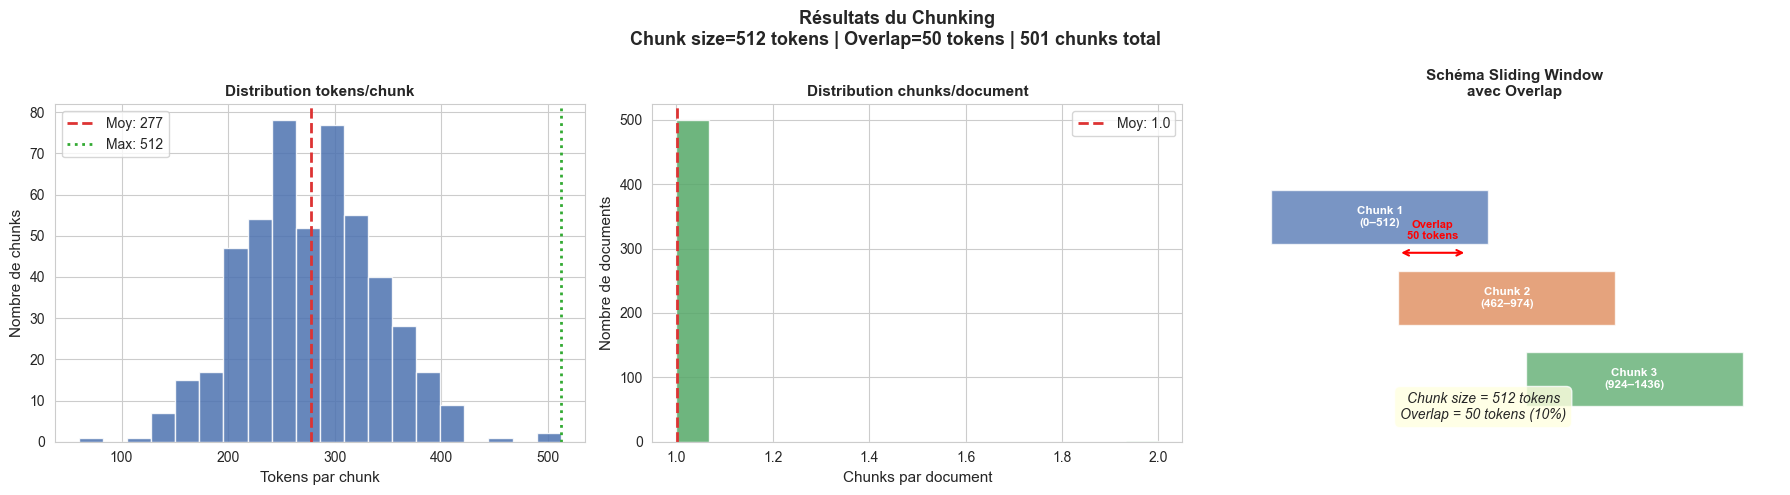

 Figure 6 sauvegardée : fig6_chunking_results.png


In [ ]:
# Distribution des tokens par chunk + chunks par document

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_style('whitegrid')
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(
    f' Résultats du Chunking\n'
    f'Chunk size={CHUNK_SIZE} tokens | Overlap={OVERLAP} tokens | '
    f'{len(all_chunks)} chunks total',
    fontsize=13, fontweight='bold'
)

# Panel 1 : Distribution tokens par chunk 
ax1 = axes[0]
ax1.hist(token_counts_chunks, bins=20,
         color='#4C72B0', edgecolor='white', alpha=0.85)
ax1.axvline(np.mean(token_counts_chunks), color='#DD3333',
            linestyle='--', linewidth=2,
            label=f'Moy: {np.mean(token_counts_chunks):.0f}')
ax1.axvline(CHUNK_SIZE, color='#33AA33',
            linestyle=':', linewidth=2,
            label=f'Max: {CHUNK_SIZE}')
ax1.set_xlabel('Tokens par chunk', fontsize=11)
ax1.set_ylabel('Nombre de chunks', fontsize=11)
ax1.set_title('Distribution tokens/chunk', fontsize=11, fontweight='bold')
ax1.legend(fontsize=10)

# Panel 2 : Chunks par document 
ax2 = axes[1]
ax2.hist(chunks_per_doc, bins=15,
         color='#55A868', edgecolor='white', alpha=0.85)
ax2.axvline(np.mean(chunks_per_doc), color='#DD3333',
            linestyle='--', linewidth=2,
            label=f'Moy: {np.mean(chunks_per_doc):.1f}')
ax2.set_xlabel('Chunks par document', fontsize=11)
ax2.set_ylabel('Nombre de documents', fontsize=11)
ax2.set_title('Distribution chunks/document', fontsize=11, fontweight='bold')
ax2.legend(fontsize=10)

#  Panel 3 : Schéma du sliding window 
ax3 = axes[2]
ax3.axis('off')

# Dessiner le schéma du chunking avec overlap
colors_chunks = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']
chunk_positions = [
    (0.00, 0.512, 'Chunk 1\n(0–512)'),
    (0.30, 0.812, 'Chunk 2\n(462–974)'),
    (0.60, 1.112, 'Chunk 3\n(924–1436)'),
]

y_base = 0.6
bar_height = 0.12

for i, (start_rel, end_rel, label) in enumerate(chunk_positions):
    y = y_base - i * 0.18
    ax3.barh(y, end_rel - start_rel, left=start_rel, height=bar_height,
             color=colors_chunks[i], alpha=0.75, edgecolor='white')
    ax3.text((start_rel + end_rel) / 2, y, label,
             ha='center', va='center', fontsize=8.5, fontweight='bold', color='white')

# Flèche overlap
ax3.annotate('', xy=(0.30, 0.52), xytext=(0.462, 0.52),
             arrowprops=dict(arrowstyle='<->', color='red', lw=1.5))
ax3.text(0.38, 0.55, f'Overlap\n{OVERLAP} tokens', ha='center',
         fontsize=8, color='red', fontweight='bold')

ax3.set_xlim(-0.05, 1.2)
ax3.set_ylim(0.1, 0.85)
ax3.set_title('Schéma Sliding Window\navec Overlap', fontsize=11, fontweight='bold')
ax3.text(0.5, 0.15,
         f'Chunk size = {CHUNK_SIZE} tokens\nOverlap = {OVERLAP} tokens ({OVERLAP/CHUNK_SIZE*100:.0f}%)',
         ha='center', fontsize=10, style='italic',
         bbox=dict(boxstyle='round,pad=0.4', facecolor='lightyellow', alpha=0.8))

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig6_chunking_results.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Figure 6 sauvegardée : fig6_chunking_results.png')

## 6 — Sauvegarde des statistiques finales 

In [ ]:
# SAUVEGARDE DES STATISTIQUES FINALES 

import json, numpy as np

# Mise à jour du dataset_stats.json
with open(RAW_DIR / 'dataset_stats.json', 'r', encoding='utf-8') as f:
    stats = json.load(f)

# Ajout des stats de chunking
stats['chunking'] = {
    'chunk_size_tokens'     : CHUNK_SIZE,
    'overlap_tokens'        : OVERLAP,
    'overlap_percent'       : round(OVERLAP / CHUNK_SIZE * 100, 1),
    'total_chunks'          : len(all_chunks),
    'chunks_per_doc_mean'   : round(float(np.mean(chunks_per_doc)), 1),
    'chunks_per_doc_max'    : int(max(chunks_per_doc)),
    'tokens_per_chunk_mean' : round(float(np.mean(token_counts_chunks)), 0),
    'tokens_per_chunk_min'  : int(min(token_counts_chunks)),
    'tokens_per_chunk_max'  : int(max(token_counts_chunks)),
    'justification'         : (
        '512 tokens = compromis entre GraphRAG (600) et LightRAG (1200). '
        'Overlap 50 tokens (10%) = standard littérature RAG pour préserver '
        'le contexte aux frontières entre chunks.'
    )
}

with open(RAW_DIR / 'dataset_stats.json', 'w', encoding='utf-8') as f:
    json.dump(stats, f, ensure_ascii=False, indent=2)

print(f'\n Résumé Semaine 3 :')
print(f'  Documents nettoyés  : {len(docs_cleaned)}')
print(f'  Chunks créés        : {len(all_chunks):,}')
print(f'  Tokens/chunk (moy.) : {np.mean(token_counts_chunks):.0f}')
print(f'  Overlap             : {OVERLAP} tokens ({OVERLAP/CHUNK_SIZE*100:.0f}%)')
print(f'\n Prochaine étape : Indexation LightRAG')


 Résumé Semaine 3 :
  Documents nettoyés  : 500
  Chunks créés        : 501
  Tokens/chunk (moy.) : 277
  Overlap             : 50 tokens (10%)

 Prochaine étape : Indexation LightRAG


---
#  Partie 3 — Indexation LightRAG + Neo4j
---

## 1 — Installation des dépendances

In [ ]:
# INSTALLATION DES DÉPENDANCES 

import subprocess, sys

packages = [
    'lightrag-hku',  # GraphRAG avec dual-level retrieval
    'groq',          # API Groq (LLM rapide et gratuit)
    'requests',      # Appels HTTP vers Ollama (embeddings)
    'numpy',         # Numpy pour les vecteurs d'embedding
    'neo4j',         # Driver Python pour Neo4j
    'networkx',      # Manipulation du graphe GraphML
    'chromadb',      # Base vectorielle ChromaDB
    'python-dotenv', # Chargement des variables d'environnement
]

for pkg in packages:
    print(f'Installation de {pkg}...')
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

print('\n Toutes les dépendances sont installées !')

Installation de lightrag-hku...
Installation de groq...
Installation de requests...
Installation de numpy...
Installation de neo4j...
Installation de networkx...
Installation de chromadb...
Installation de python-dotenv...

 Toutes les dépendances sont installées !


## 2 — Configuration de l'environnement


In [4]:
# CONFIGURATION DE L'ENVIRONNEMENT 
# Chargement des clés API depuis .env 

import os
import json
import asyncio
import requests
import numpy as np
import shutil
from pathlib import Path
from dotenv import load_dotenv

# Chargement du .env
load_dotenv()

#  Clé Groq 
GROQ_API_KEY = os.getenv('GROQ_API_KEY', '')

if not GROQ_API_KEY:
    print('  GROQ_API_KEY non trouvée dans .env')
else:
    print(f' GROQ_API_KEY chargée depuis .env ')

#  Chemins des répertoires et fichiers
LIGHTRAG_DIR  = Path('indexes/lightrag')
CHROMA_DIR    = Path('indexes/chroma_db')
RESULTS_DIR   = Path('data/processed')
FIGURES_DIR   = Path('figures')
CHECKPOINT    = Path('data/processed/checkpoint.json')

for d in [LIGHTRAG_DIR, CHROMA_DIR, RESULTS_DIR, FIGURES_DIR]:
    d.mkdir(parents=True, exist_ok=True)

#  Paramètres
NB_DOCS_TEST  = 100   #  test sur 100 documents
GROQ_MODEL    = 'llama-3.1-8b-instant'  # Modèle recommandé pour GraphRAG
EMBED_MODEL   = 'nomic-embed-text'       # Modèle embedding local via Ollama
EMBED_DIM     = 768                      # Dimension réelle de nomic-embed-text
OLLAMA_URL    = 'http://localhost:11434' # URL Ollama local

print('\n  Configuration :')
print(f'  Modèle LLM       : {GROQ_MODEL} (Groq API)')
print(f'  Modèle Embedding : {EMBED_MODEL} (Ollama local)')
print(f'  Dimension embed. : {EMBED_DIM}')
print(f'  Documents test   : {NB_DOCS_TEST}')
print(f'  Répertoire index : {LIGHTRAG_DIR}')

 GROQ_API_KEY chargée depuis .env 

  Configuration :
  Modèle LLM       : llama-3.1-8b-instant (Groq API)
  Modèle Embedding : nomic-embed-text (Ollama local)
  Dimension embed. : 768
  Documents test   : 100
  Répertoire index : indexes\lightrag


## 3 — Test de connexion Ollama + Groq

In [5]:
# TEST DE CONNEXION OLLAMA + GROQ
# Vérification que tout fonctionne avant de lancer l'indexation

import requests
from groq import Groq

print(' Test des connexions...\n')

#  Test 1 : Ollama embedding 
print('1️  Test Ollama (embedding nomic-embed-text)...')
try:
    resp = requests.post(
        f'{OLLAMA_URL}/api/embeddings',
        json={'model': EMBED_MODEL, 'prompt': 'test connexion'},
        timeout=30
    )
    emb = resp.json()['embedding']
    print(f'  Ollama OK — dimension embedding : {len(emb)} (attendu : {EMBED_DIM})')
    
    if len(emb) != EMBED_DIM:
        print(f' Dimension inattendue ! Mettre EMBED_DIM = {len(emb)} dans la config')
        EMBED_DIM = len(emb)
except Exception as e:
    print(f' Ollama inaccessible : {e}')
    print('  Lance : ollama serve  (dans un terminal séparé)')
    print('  Puis  : ollama pull nomic-embed-text')

#  Test 2 : Groq API 
print('\n2️  Test Groq API (llama-3.1-8b-instant)...')
try:
    client_test = Groq(api_key=GROQ_API_KEY)
    resp_groq = client_test.chat.completions.create(
        model=GROQ_MODEL,
        messages=[{'role': 'user', 'content': 'Reply with exactly: OK'}],
        max_tokens=10
    )
    print(f'  Groq OK — réponse : {resp_groq.choices[0].message.content.strip()}')
except Exception as e:
    print(f'   Groq inaccessible : {e}')
    print('    Vérifier la clé API dans .env')

print('\n Tests terminés — Prêt pour l\'indexation')

 Test des connexions...

1️  Test Ollama (embedding nomic-embed-text)...
  Ollama OK — dimension embedding : 768 (attendu : 768)

2️  Test Groq API (llama-3.1-8b-instant)...
  Groq OK — réponse : OK

 Tests terminés — Prêt pour l'indexation


## 4 — Fonctions LLM (Groq) et Embedding (Ollama)

In [6]:
# ============================================================
# FONCTIONS LLM ET EMBEDDING POUR LIGHTRAG
# 
# Architecture :
#   - LLM     : Groq API (rapide, gratuit, llama-3.1-8b)
#   - Embedding : Ollama local (nomic-embed-text, 768 dim)
#
# Pourquoi cette séparation ?
#   - Groq est rapide pour l'extraction d'entités (texte court)
#   - Ollama est gratuit et illimité pour les embeddings
# ============================================================

import asyncio
import requests
import numpy as np
from groq import AsyncGroq

# Client Groq asynchrone
groq_client = AsyncGroq(api_key=GROQ_API_KEY)

import requests

async def local_llm_func(prompt, system_prompt=None, history_messages=[], **kwargs):

    messages = []

    if system_prompt:
        messages.append({"role": "system", "content": system_prompt})

    for msg in history_messages:
        messages.append(msg)

    messages.append({"role": "user", "content": prompt})

    response = requests.post(
        "http://localhost:11434/api/chat",
        json={
            "model": "llama3.1:8b ",
            "messages": messages,
            "stream": False
        }
    )

    return response.json()["message"]["content"]


async def groq_llm_func(prompt, system_prompt=None, history_messages=[], **kwargs):
    """
    Fonction LLM pour LightRAG : utilise Groq API.
    
    Inclut un mécanisme de retry automatique :
    - Si rate limit (429) -> attend et réessaie
    - Backoff exponentiel : 60s, 120s, 180s, 240s, 300s
    - Max 5 tentatives avant d'abandonner
    """
    messages = []
    if system_prompt:
        messages.append({'role': 'system', 'content': system_prompt})
    for msg in history_messages:
        messages.append(msg)
    messages.append({'role': 'user', 'content': prompt})

    for attempt in range(5):
        try:
            response = await groq_client.chat.completions.create(
                model=GROQ_MODEL,
                messages=messages,
                max_tokens=300,    # Limité pour économiser le quota
                temperature=0,     # Déterministe = meilleure qualité
            )
            return response.choices[0].message.content
            
        except Exception as e:
            if '429' in str(e):
                # Rate limit Groq — attendre et réessayer
                wait_time = 60 * (attempt + 1)
                print(f'\n  Rate limit Groq — attente {wait_time}s '
                      f'(tentative {attempt+1}/5)...')
                await asyncio.sleep(wait_time)
            else:
                # Autre erreur propager
                raise e
    
    return 'Erreur LLM après 5 tentatives'


async def embedding_func(texts):
    """
    Fonction d'embedding pour LightRAG : utilise Ollama local.
    
    Retourne un tableau NumPy 2D de shape (n_textes, 768).
    
    IMPORTANT : LightRAG attend un numpy array, pas une liste Python.
    Solution : np.vstack() pour créer un tableau 2D correct.
    """
    embeddings = []
    
    for text in texts:
        response = requests.post(
            f'{OLLAMA_URL}/api/embeddings',
            json={'model': EMBED_MODEL, 'prompt': text},
            timeout=60
        )
        # Convertir en numpy float32 (plus efficace que float64)
        emb = np.array(response.json()['embedding'], dtype=np.float32)
        embeddings.append(emb)
    
    # CRITIQUE : retourner np.vstack, pas une liste
    # np.vstack crée un tableau 2D (n_textes, dim)
    return np.vstack(embeddings)


print(' Fonctions LLM et Embedding définies')
print(f'   LLM      : Groq API -> {GROQ_MODEL}')
print(f'   Embedding : Ollama -> {EMBED_MODEL} ({EMBED_DIM} dimensions)')

 Fonctions LLM et Embedding définies
   LLM      : Groq API -> llama-3.1-8b-instant
   Embedding : Ollama -> nomic-embed-text (768 dimensions)


## 5 — Indexation LightRAG avec checkpoint

**Ce que fait cette partie :**
1. Initialise LightRAG avec le graphe vide
2. Indexe 100 documents avec checkpoint (reprise automatique en cas d'erreur)
3. Sauvegarde le graphe dans `indexes/lightrag/`

In [ ]:
# ============================================================
# INDEXATION LIGHTRAG AVEC CHECKPOINT
# 
# Pipeline :
#   1. LightRAG reçoit le texte (titre + abstract)
#   2. Groq LLM extrait les entités et relations
#   3. Ollama embedding vectorise chaque entité
#   4. Le graphe est sauvegardé dans indexes/lightrag/
# 
# Checkpoint : si le script s'arrête, il reprend où il
# s'est arrêté sans recommencer depuis le début.
# ============================================================

import asyncio
import json
from pathlib import Path
from lightrag import LightRAG, QueryParam
from lightrag.utils import EmbeddingFunc
import nest_asyncio
nest_asyncio.apply()


# Fonctions de checkpoint 
def load_checkpoint():
    """Charge la progression depuis le fichier checkpoint."""
    if CHECKPOINT.exists():
        with open(CHECKPOINT, 'r') as f:
            state = json.load(f)
        print(f' Checkpoint trouvé, reprise à partir du document {state["last_index"]}')
        return state
    return {'last_index': 0, 'success': 0, 'errors': []}

def save_checkpoint(state):
    """Sauvegarde la progression dans le fichier checkpoint."""
    with open(CHECKPOINT, 'w') as f:
        json.dump(state, f, indent=2)


# Fonction principale d'indexation
async def run_indexation():
    """
    Lance l'indexation de 100 documents dans LightRAG.
    Utilise Groq pour l'extraction et Ollama pour les embeddings.
    """

    #  1. Nettoyer l'ancien index si demandé 
    import shutil
    reset = input('\nSupprimer l\'ancien index et recommencer ? (o/N) : ').strip().lower()
    if reset == 'o':
        if LIGHTRAG_DIR.exists():
            shutil.rmtree(LIGHTRAG_DIR)
        if CHECKPOINT.exists():
            CHECKPOINT.unlink()
        LIGHTRAG_DIR.mkdir(parents=True, exist_ok=True)
        print(' Ancien index supprimé , indexation depuis le début')
    else:
        LIGHTRAG_DIR.mkdir(parents=True, exist_ok=True)
        print(' Conservation de l\'index existant , reprise du checkpoint')

    #  2. Initialisation de LightRAG
    print('\n Initialisation de LightRAG...')
    rag = LightRAG(
        working_dir=str(LIGHTRAG_DIR),
        llm_model_func=local_llm_func,
        embedding_func=EmbeddingFunc(
            embedding_dim=EMBED_DIM,      # 768 pour nomic-embed-text
            max_token_size=512,           # Taille max du chunk
            func=embedding_func,
        ),
    )
    await rag.initialize_storages()
    print('LightRAG initialisé')

    #  3. Chargement des documents
    PROCESSED_DIR = Path('data/processed')
    with open(PROCESSED_DIR / 'arxiv_cleaned.json', 'r', encoding='utf-8') as f:
        docs_all = json.load(f)

    docs_100 = docs_all[:NB_DOCS_TEST]
    print(f' {len(docs_100)} documents à indexer')

    #  4. Chargement du checkpoint
    state = load_checkpoint()
    start_idx = state['last_index']
    success = state['success']
    errors = state['errors']

    #  5. Indexation avec checkpoint 
    print(f'\n Indexation en cours (début à l\'index {start_idx})...')
    print('   LLM : Groq (llama-3.1-8b-instant)')
    print('   Embedding : Ollama (nomic-embed-text, 768 dim)\n')

    for i in range(start_idx, len(docs_100)):
        doc = docs_100[i]

        # Texte à indexer : titre + abstract 
        # Environ 300-500 tokens par document
        texte = doc['text']  

        try:
            await rag.ainsert(texte)
            success += 1
            print(f'  [{success}/{NB_DOCS_TEST}] {doc["title"][:60]}...')

        except Exception as e:
            errors.append({'index': i, 'id': doc['id'], 'error': str(e)[:100]})
            print(f' [{i}] Erreur : {str(e)[:80]}')
            await asyncio.sleep(5)

        finally:
            # Sauvegarder le checkpoint après chaque document
            state = {'last_index': i + 1, 'success': success, 'errors': errors}
            save_checkpoint(state)

        # Petite pause entre les documents (pour respecter les limites Groq)
        await asyncio.sleep(2)

    print(f'\n Indexation terminée !')
    print(f'   Succès  : {success}/{NB_DOCS_TEST}')
    print(f'   Erreurs : {len(errors)}')

    return rag


#  Lancement de l'indexation 
print('  INDEXATION LIGHTRAG')
print('  100 documents test (titre + abstract)')

rag = asyncio.run(run_indexation())

  INDEXATION LIGHTRAG
  100 documents test (titre + abstract)
 Conservation de l'index existant , reprise du checkpoint

 Initialisation de LightRAG...


INFO: [] Loaded graph from indexes\lightrag\graph_chunk_entity_relation.graphml with 1355 nodes, 620 edges
INFO:nano-vectordb:Load (1355, 768) data
INFO:nano-vectordb:Init {'embedding_dim': 768, 'metric': 'cosine', 'storage_file': 'indexes\\lightrag\\vdb_entities.json'} 1355 data
INFO:nano-vectordb:Load (620, 768) data
INFO:nano-vectordb:Init {'embedding_dim': 768, 'metric': 'cosine', 'storage_file': 'indexes\\lightrag\\vdb_relationships.json'} 620 data
INFO:nano-vectordb:Load (100, 768) data
INFO:nano-vectordb:Init {'embedding_dim': 768, 'metric': 'cosine', 'storage_file': 'indexes\\lightrag\\vdb_chunks.json'} 100 data
INFO: [] Process 6672 KV load full_docs with 100 records
INFO: [] Process 6672 KV load text_chunks with 100 records
INFO: [] Process 6672 KV load full_entities with 100 records
INFO: [] Process 6672 KV load full_relations with 100 records
INFO: [] Process 6672 KV load entity_chunks with 1355 records
INFO: [] Process 6672 KV load relation_chunks with 620 records
INFO: []

LightRAG initialisé
 100 documents à indexer
 Checkpoint trouvé, reprise à partir du document 100

 Indexation en cours (début à l'index 100)...
   LLM : Groq (llama-3.1-8b-instant)
   Embedding : Ollama (nomic-embed-text, 768 dim)


 Indexation terminée !
   Succès  : 95/100
   Erreurs : 0


## LightRAG -> ChromaDB : stockage des chunks dans chromadb


In [1]:
# ============================================================
# EXPORT DES CHUNKS LIGHTRAG → CHROMADB (FIXÉ)
# ============================================================

import json
from pathlib import Path
import chromadb
import requests

# Dossiers
LIGHTRAG_DIR = Path("indexes/lightrag")
CHROMA_DIR = Path("indexes/chroma_db")

CHROMA_DIR.mkdir(parents=True, exist_ok=True)

# Charger les chunks LightRAG
chunks_path = LIGHTRAG_DIR / "kv_store_text_chunks.json"

with open(chunks_path, "r", encoding="utf-8") as f:
    chunks_data = json.load(f)

print(f"{len(chunks_data)} chunks chargés")

# ChromaDB persistent
client = chromadb.PersistentClient(
    path=str(CHROMA_DIR)
)

collection = client.get_or_create_collection(
    name="rag_chunks"
)

# Embedding via Ollama
def embed(text):
    response = requests.post(
        "http://localhost:11434/api/embeddings",
        json={
            "model": "nomic-embed-text",
            "prompt": text[:1000]
        },
        timeout=60
    )
    return response.json()["embedding"]

# Indexation
ids = []
documents = []
embeddings = []

for i, (chunk_id, chunk) in enumerate(chunks_data.items()):

    # content au lieu de text
    text = chunk.get("content", "").strip()

    if not text:
        continue

    try:
        emb = embed(text)

        ids.append(str(chunk_id))
        documents.append(text)
        embeddings.append(emb)

        # Batch insert
        if len(ids) >= 20:
            collection.add(
                ids=ids,
                documents=documents,
                embeddings=embeddings,
                metadatas=[{"source": "lightrag"} for _ in ids]
            )

            print(f"Batch inséré : {len(ids)} chunks")

            ids, documents, embeddings = [], [], []

        print(f"[{i}] ajouté")

    except Exception as e:
        print(f"Erreur chunk {chunk_id}: {e}")

# Insert reste
if ids:
    collection.add(
        ids=ids,
        documents=documents,
        embeddings=embeddings,
        metadatas=[{"source": "lightrag"} for _ in ids]
    )
    print(f"Batch final inséré : {len(ids)} chunks")

# Vérification
print("\nChromaDB rempli avec succès !")
print(f"Dossier : {CHROMA_DIR}")
print("Nb documents dans Chroma :", collection.count())

100 chunks chargés
[0] ajouté
[1] ajouté
[2] ajouté
[3] ajouté
[4] ajouté
[5] ajouté
[6] ajouté
[7] ajouté
[8] ajouté
[9] ajouté
[10] ajouté
[11] ajouté
[12] ajouté
[13] ajouté
[14] ajouté
[15] ajouté
[16] ajouté
[17] ajouté
[18] ajouté
Batch inséré : 20 chunks
[19] ajouté
[20] ajouté
[21] ajouté
[22] ajouté
[23] ajouté
[24] ajouté
[25] ajouté
[26] ajouté
[27] ajouté
[28] ajouté
[29] ajouté
[30] ajouté
[31] ajouté
[32] ajouté
[33] ajouté
[34] ajouté
[35] ajouté
[36] ajouté
[37] ajouté
[38] ajouté
Batch inséré : 20 chunks
[39] ajouté
[40] ajouté
[41] ajouté
[42] ajouté
[43] ajouté
[44] ajouté
[45] ajouté
[46] ajouté
[47] ajouté
[48] ajouté
[49] ajouté
[50] ajouté
[51] ajouté
[52] ajouté
[53] ajouté
[54] ajouté
[55] ajouté
[56] ajouté
[57] ajouté
[58] ajouté
Batch inséré : 20 chunks
[59] ajouté
[60] ajouté
[61] ajouté
[62] ajouté
[63] ajouté
[64] ajouté
[65] ajouté
[66] ajouté
[67] ajouté
[68] ajouté
[69] ajouté
[70] ajouté
[71] ajouté
[72] ajouté
[73] ajouté
[74] ajouté
[75] ajouté
[76]

In [16]:
from pathlib import Path

neo4j_dir = Path("neo4j_data")

print(" Contenu du dossier neo4j_data :\n")

if not neo4j_dir.exists():
    print(" Le dossier neo4j_data n'existe pas")
else:
    for path in neo4j_dir.rglob("*"):
        if path.is_file():
            print("FILE  :", path.relative_to(neo4j_dir))
        else:
            print("DIR   :", path.relative_to(neo4j_dir))

 Contenu du dossier neo4j_data :

DIR   : databases
DIR   : dbms
FILE  : server_id
DIR   : transactions
DIR   : databases\neo4j
FILE  : databases\store_lock
DIR   : databases\system
FILE  : dbms\auth.ini
DIR   : transactions\neo4j
DIR   : transactions\system
FILE  : databases\neo4j\database_lock
FILE  : databases\neo4j\id-buffer.tmp.0
FILE  : databases\neo4j\neostore
FILE  : databases\neo4j\neostore.counts.db
FILE  : databases\neo4j\neostore.indexstats.db
FILE  : databases\neo4j\neostore.labeltokenstore.db
FILE  : databases\neo4j\neostore.labeltokenstore.db.id
FILE  : databases\neo4j\neostore.labeltokenstore.db.names
FILE  : databases\neo4j\neostore.labeltokenstore.db.names.id
FILE  : databases\neo4j\neostore.nodestore.db
FILE  : databases\neo4j\neostore.nodestore.db.id
FILE  : databases\neo4j\neostore.nodestore.db.labels
FILE  : databases\neo4j\neostore.nodestore.db.labels.id
FILE  : databases\neo4j\neostore.propertystore.db
FILE  : databases\neo4j\neostore.propertystore.db.arrays
FIL

## 6 — Test des modes naive et hybrid

In [8]:
# TEST DES MODES NAIVE ET HYBRID 
# Mode NAIVE  : RAG classique qui cherche les chunks similaires
# Mode HYBRID : LightRAG complet contenant le graphe + vecteurs combinés

import asyncio, json
from lightrag import QueryParam

async def run_tests(rag):

    questions = [
        'What are the main methods used in machine learning for classification?',
        'How do graph neural networks improve knowledge representation?',
        'What are the limitations of transformer models in NLP?',
    ]

    results = []

    for question in questions:
        print(f'\n Question : {question}')

        result_entry = {'question': question, 'naive': '', 'hybrid': ''}

        # =========================
        # NAIVE MODE (FIX TOKENS)
        # =========================
        print('\n MODE NAIVE:')

        try:
            naive_result = await rag.aquery(
                question,
                param=QueryParam(
                    mode='naive',
                    top_k=15,              # CRITICAL FIX
                    enable_rerank=False
                )
            )

            result_entry['naive'] = str(naive_result) if naive_result else "EMPTY"
            print(result_entry['naive'][:400])

        except Exception as e:
            print(f'Naive error: {e}')
            result_entry['naive'] = f'Error: {e}'

        await asyncio.sleep(2)

        # =========================
        # HYBRID MODE (FIX TOKENS)
        # =========================
        print('\n MODE HYBRID:')

        try:
            hybrid_result = await rag.aquery(
                question,
                param=QueryParam(
                    mode='hybrid',
                    top_k=20,
                    chunk_top_k=15,              # CRITICAL FIX
                    enable_rerank=False
                )
            )

            result_entry['hybrid'] = str(hybrid_result) if hybrid_result else "EMPTY"
            print(result_entry['hybrid'][:400])

        except Exception as e:
            print(f'Hybrid error: {e}')
            result_entry['hybrid'] = f'Error: {e}'

        results.append(result_entry)

        await asyncio.sleep(2)

    return results


# =========================
# RUN SAFE TEST
# =========================

print("Running optimized LightRAG tests...")

if 'rag' not in globals():
    raise Exception(" rag not defined. Run indexation first.")

results = asyncio.run(run_tests(rag))

with open(RESULTS_DIR / 'comparison_naive_hybrid.json', 'w', encoding='utf-8') as f:
    json.dump(results, f, ensure_ascii=False, indent=2)

print("Done. Results saved.")

INFO: Embedding func: 8 new workers initialized (Timeouts: Func: 30s, Worker: 60s, Health Check: 75s)


Running optimized LightRAG tests...

 Question : What are the main methods used in machine learning for classification?

 MODE NAIVE:


INFO: Naive query: 20 chunks (chunk_top_k:20 cosine:0.2)
INFO: Final context: 20 chunks
INFO: LLM func: 4 new workers initialized (Timeouts: Func: 180s, Worker: 360s, Health Check: 375s)
INFO:  == LLM cache == saving: naive:query:ebebe2bd29476b7dd3e88adcc704abb8


There are several main methods used in machine learning for classification, including:

1. **Logistic Regression**: This is a popular and widely-used method for binary classification problems (e.g., spam vs. non-spam emails). It models the probability of an instance belonging to one class using a logistic function.
2. **Support Vector Machines (SVMs)**: SVMs are a type of supervised learning algor

 MODE HYBRID:


INFO: Query nodes: Supervised learning, Neural networks, Decision trees, Support vector machines, K-nearest neighbors (top_k:20, cosine:0.2)
INFO: Local query: 20 entites, 17 relations
INFO: Query edges: Machine learning, Classification, Methods (top_k:20, cosine:0.2)
INFO: Global query: 32 entites, 20 relations
INFO: Raw search results: 47 entities, 29 relations, 0 vector chunks
INFO: After truncation: 47 entities, 29 relations
INFO: Selecting 32 from 32 entity-related chunks by vector similarity
INFO: Find no additional relations-related chunks from 29 relations
INFO: Round-robin merged chunks: 32 -> 32 (deduplicated 0)
INFO: Final context: 47 entities, 29 relations, 15 chunks
INFO: Final chunks S+F/O: E4/1 E3/2 E3/3 E1/4 E8/5 E2/6 E1/7 E2/8 E1/9 E2/10 E1/11 E3/12 E2/13 E1/14 E4/15
INFO:  == LLM cache == saving: hybrid:query:8b71da66a2db96b45268527620f14878


...

Graph Neural Networks (GNNs) have revolutionized the way we represent and analyze complex data, particularly in domains like social networks, molecules, and recommendation systems. Here's how GNNs can improve knowledge representation:

1. **Structured Data Representation**: Graphs are an ideal data structure for representing structured data with inherent relationships between entities. GNNs can le

 Question : What are the limitations of transformer models in NLP?

 MODE NAIVE:


INFO: Naive query: 20 chunks (chunk_top_k:20 cosine:0.2)
INFO: Final context: 20 chunks
INFO:  == LLM cache == saving: naive:query:d790b57a9e15a805257b33ccefd63009


The document chunks do not explicitly mention the limitations of transformer models in NLP. However, I can provide some common limitations of transformer models:

1. **Computational Cost**: Transformer models require large amounts of memory and computation power to process long sequences, making them computationally expensive.

2. **Training Data Requirements**: Large quantities of high-quality tr

 MODE HYBRID:


INFO: Query nodes: Attention mechanism, Self-supervised learning, Language understanding, Model evaluation metrics, Deep learning (top_k:20, cosine:0.2)
INFO: Local query: 20 entites, 19 relations
INFO: Query edges: Transformer models, NLP limitations (top_k:20, cosine:0.2)
INFO: Global query: 30 entites, 20 relations
INFO: Raw search results: 50 entities, 39 relations, 0 vector chunks
INFO: After truncation: 50 entities, 39 relations
INFO: Selecting 53 from 53 entity-related chunks by vector similarity
INFO: Find no additional relations-related chunks from 39 relations
INFO: Round-robin merged chunks: 53 -> 53 (deduplicated 0)
INFO: Final context: 50 entities, 39 relations, 15 chunks
INFO: Final chunks S+F/O: E1/1 E1/2 E1/3 E1/4 E3/5 E3/6 E2/7 E1/8 E1/9 E1/10 E1/11 E1/12 E3/13 E1/14 E1/15
INFO:  == LLM cache == saving: hybrid:query:5f2926f97afff0ffad5e8716df1fce4f


Transformer models have been widely adopted in various Natural Language Processing (NLP) tasks due to their ability to capture complex relationships between input elements using self-attention mechanisms. However, like any other model architecture, they also have several limitations:

1. **Computational Complexity**: Transformer models are computationally expensive due to the quadratic complexity 
Done. Results saved.


## 7 — Visualisation comparative naive vs hybrid

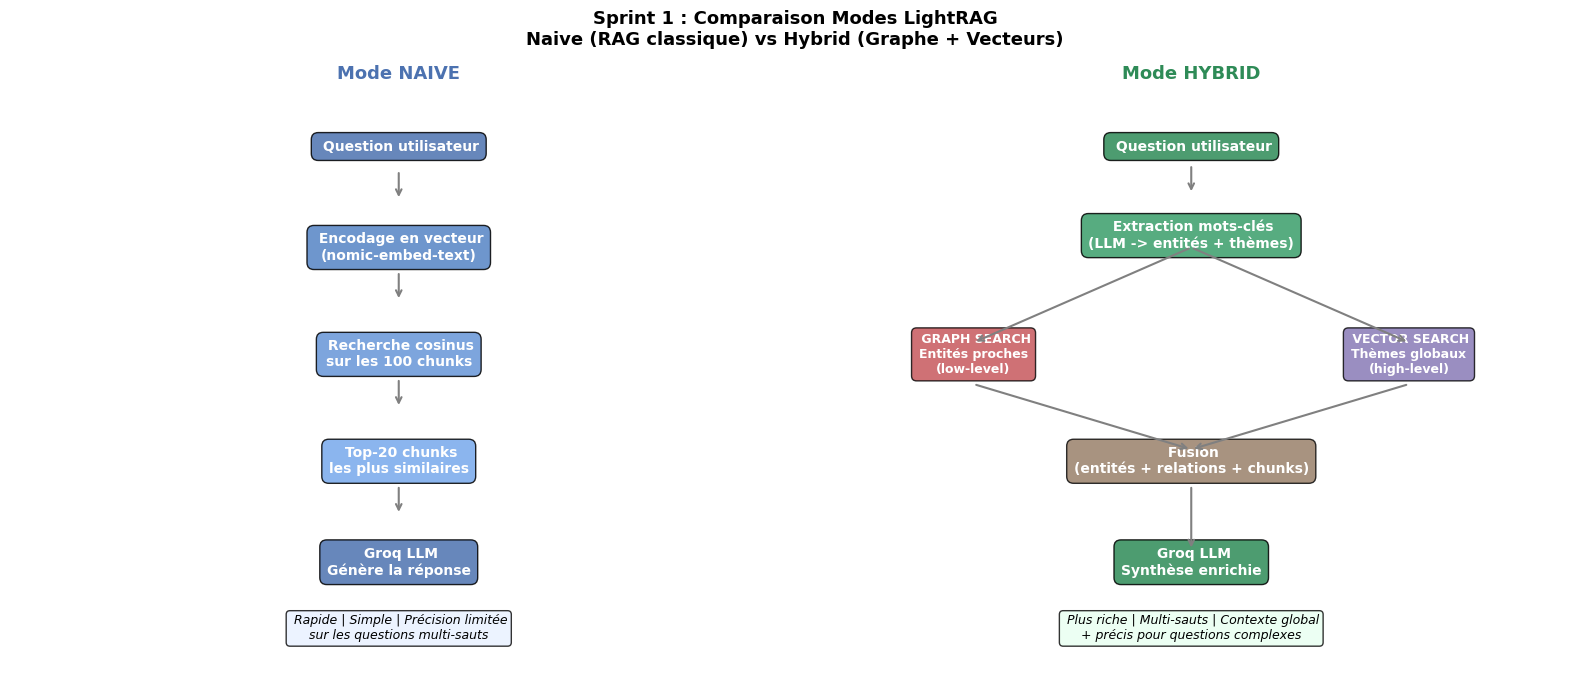

 Figure 7 sauvegardée : fig7_naive_vs_hybrid.png


In [10]:
# VISUALISATION : COMPARAISON NAIVE VS HYBRID

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle(
    'Sprint 1 : Comparaison Modes LightRAG\nNaive (RAG classique) vs Hybrid (Graphe + Vecteurs)',
    fontsize=13, fontweight='bold'
)

#  Panel gauche : Schéma Mode NAIVE 
ax1 = axes[0]
ax1.axis('off')
ax1.set_title('Mode NAIVE', fontsize=13, fontweight='bold', color='#4C72B0')

steps_naive = [
    (0.5, 0.90, ' Question utilisateur', '#4C72B0'),
    (0.5, 0.73, ' Encodage en vecteur\n(nomic-embed-text)', '#5584C5'),
    (0.5, 0.55, ' Recherche cosinus\nsur les 100 chunks', '#6696D8'),
    (0.5, 0.37, ' Top-20 chunks\nles plus similaires', '#77A8EB'),
    (0.5, 0.20, ' Groq LLM\nGénère la réponse', '#4C72B0'),
]

for i, (x, y, text, color) in enumerate(steps_naive):
    ax1.text(x, y, text, ha='center', va='center', fontsize=10,
             bbox=dict(boxstyle='round,pad=0.5', facecolor=color, alpha=0.85),
             color='white', fontweight='bold', transform=ax1.transAxes)
    if i < len(steps_naive) - 1:
        ax1.annotate('', xy=(x, y - 0.09), xytext=(x, y - 0.04),
                     xycoords='axes fraction', textcoords='axes fraction',
                     arrowprops=dict(arrowstyle='->', color='gray', lw=1.5))

ax1.text(0.5, 0.07, ' Rapide | Simple | Précision limitée\nsur les questions multi-sauts',
         ha='center', fontsize=9, style='italic',
         bbox=dict(boxstyle='round', facecolor='#E8F0FF', alpha=0.8),
         transform=ax1.transAxes)


#  Panel droit : Schéma Mode HYBRID 
ax2 = axes[1]
ax2.axis('off')
ax2.set_title('Mode HYBRID', fontsize=13, fontweight='bold', color='#2E8B57')

# Noeuds
ax2.text(0.5, 0.90, ' Question utilisateur', ha='center', va='center', fontsize=10,
         bbox=dict(boxstyle='round,pad=0.5', facecolor='#2E8B57', alpha=0.85),
         color='white', fontweight='bold', transform=ax2.transAxes)

ax2.text(0.5, 0.75, ' Extraction mots-clés\n(LLM -> entités + thèmes)', ha='center', va='center', fontsize=10,
         bbox=dict(boxstyle='round,pad=0.5', facecolor='#3A9E6A', alpha=0.85),
         color='white', fontweight='bold', transform=ax2.transAxes)

ax2.text(0.22, 0.55, ' GRAPH SEARCH\nEntités proches\n(low-level)',
         ha='center', va='center', fontsize=9,
         bbox=dict(boxstyle='round,pad=0.4', facecolor='#C44E52', alpha=0.8),
         color='white', fontweight='bold', transform=ax2.transAxes)

ax2.text(0.78, 0.55, ' VECTOR SEARCH\nThèmes globaux\n(high-level)',
         ha='center', va='center', fontsize=9,
         bbox=dict(boxstyle='round,pad=0.4', facecolor='#8172B2', alpha=0.8),
         color='white', fontweight='bold', transform=ax2.transAxes)

ax2.text(0.5, 0.37, ' Fusion\n(entités + relations + chunks)',
         ha='center', va='center', fontsize=10,
         bbox=dict(boxstyle='round,pad=0.5', facecolor='#937860', alpha=0.8),
         color='white', fontweight='bold', transform=ax2.transAxes)

ax2.text(0.5, 0.20, ' Groq LLM\nSynthèse enrichie', ha='center', va='center',
         fontsize=10,
         bbox=dict(boxstyle='round,pad=0.5', facecolor='#2E8B57', alpha=0.85),
         color='white', fontweight='bold', transform=ax2.transAxes)


#  FLECHES HYBRID (réduites / plus courtes)
ax2.annotate('', xy=(0.5, 0.82), xytext=(0.5, 0.87),
             xycoords='axes fraction', textcoords='axes fraction',
             arrowprops=dict(arrowstyle='->', color='gray', lw=1.5))

ax2.annotate('', xy=(0.22, 0.57), xytext=(0.5, 0.73),
             xycoords='axes fraction', textcoords='axes fraction',
             arrowprops=dict(arrowstyle='->', color='gray', lw=1.5))

ax2.annotate('', xy=(0.78, 0.57), xytext=(0.5, 0.73),
             xycoords='axes fraction', textcoords='axes fraction',
             arrowprops=dict(arrowstyle='->', color='gray', lw=1.5))

ax2.annotate('', xy=(0.5, 0.39), xytext=(0.22, 0.50),
             xycoords='axes fraction', textcoords='axes fraction',
             arrowprops=dict(arrowstyle='->', color='gray', lw=1.5))

ax2.annotate('', xy=(0.5, 0.39), xytext=(0.78, 0.50),
             xycoords='axes fraction', textcoords='axes fraction',
             arrowprops=dict(arrowstyle='->', color='gray', lw=1.5))

ax2.annotate('', xy=(0.5, 0.22), xytext=(0.5, 0.33),
             xycoords='axes fraction', textcoords='axes fraction',
             arrowprops=dict(arrowstyle='->', color='gray', lw=1.5))


ax2.text(0.5, 0.07,
         ' Plus riche | Multi-sauts | Contexte global\n+ précis pour questions complexes',
         ha='center', fontsize=9, style='italic',
         bbox=dict(boxstyle='round', facecolor='#E8FFF0', alpha=0.8),
         transform=ax2.transAxes)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig7_naive_vs_hybrid.png', dpi=150, bbox_inches='tight')
plt.show()

print(' Figure 7 sauvegardée : fig7_naive_vs_hybrid.png')

## 8 — Export du graphe vers Neo4j

In [11]:
# EXPORT DU GRAPHE LIGHTRAG VERS NEO4J
# 
# LightRAG génère un fichier GraphML dans indexes/lightrag/ , donc on l'exporte vers Neo4j pour visualisation dans le Browser.
# 
# Prérequis : Neo4j doit tourner via Docker
#   docker run -p 7474:7474 -p 7687:7687 \
#     -e NEO4J_AUTH=neo4j/password123 \
#     neo4j:5.13.0

import networkx as nx
from neo4j import GraphDatabase
from pathlib import Path

# Config Neo4j
NEO4J_URI      = 'bolt://localhost:7687'
NEO4J_USER     = 'neo4j'
NEO4J_PASSWORD = 'password123'
GRAPHML_PATH   = LIGHTRAG_DIR / 'graph_chunk_entity_relation.graphml'


def export_to_neo4j(graphml_path, uri, user, password):
    """
    Exporte le graphe LightRAG (GraphML) vers Neo4j.
    
    Étapes :
    1. Charger le GraphML avec NetworkX
    2. Vider l'ancienne base Neo4j
    3. Insérer tous les nœuds (entités)
    4. Insérer toutes les arêtes (relations RELATES_TO)
    """
    #  1. Vérifier que le fichier GraphML existe
    if not graphml_path.exists():
        print(f' Fichier GraphML non trouvé : {graphml_path}')
        return False

    #  2. Charger le graphe avec NetworkX 
    print(' Chargement du graphe GraphML...')
    graph = nx.read_graphml(str(graphml_path))
    print(f'   Nœuds     : {len(graph.nodes())}')
    print(f'   Relations : {len(graph.edges())}')

    #  3. Connexion à Neo4j 
    print('\n Connexion à Neo4j...')
    try:
        driver = GraphDatabase.driver(uri, auth=(user, password))
        driver.verify_connectivity()
        print('   Connexion Neo4j établie')
    except Exception as e:
        print(f'   Connexion Neo4j échouée : {e}')
        print('    Vérifier que Neo4j tourne : docker ps')
        return False

    #  4. Import dans Neo4j 
    def import_graph(tx, graph):
        # Vider l'ancienne base
        print('   Suppression de l\'ancien graphe...')
        tx.run('MATCH (n) DETACH DELETE n')

        # Insérer les nœuds
        print(f'  Insertion de {len(graph.nodes())} nœuds...')
        for node, data in graph.nodes(data=True):
            tx.run(
                '''
                MERGE (e:Entity {id: $id})
                SET e.name        = $name,
                    e.type        = $type,
                    e.description = $desc
                ''',
                id=node,
                name=data.get('name') or node,
                type=data.get('type', ''),
                desc=data.get('description', '')[:500]  # Limiter la taille
            )

        # Insérer les relations
        print(f'  Insertion de {len(graph.edges())} relations...')
        for source, target, data in graph.edges(data=True):
            tx.run(
                '''
                MATCH (a:Entity {id: $src})
                MATCH (b:Entity {id: $tgt})
                MERGE (a)-[r:RELATES_TO]->(b)
                SET r.description = $desc
                ''',
                src=source,
                tgt=target,
                desc=data.get('description', '')[:300]
            )

    with driver.session() as session:
        session.execute_write(import_graph, graph)

    print('\n Export vers Neo4j terminé !')
    print(f'   Nœuds     : {len(graph.nodes())}')
    print(f'   Relations : {len(graph.edges())}')
    print('\n Ouvre Neo4j Browser : http://localhost:7474')
    print('   Requêtes Cypher pour explorer le graphe :')
    print("   -> MATCH (a)-[r]->(b) RETURN a,r,b LIMIT 50")
    print("   -> MATCH (n:Entity)-[r]-() RETURN n.name, count(r) "
          "ORDER BY count(r) DESC LIMIT 10")

    driver.close()
    return True


# Lancer l'export
export_to_neo4j(GRAPHML_PATH, NEO4J_URI, NEO4J_USER, NEO4J_PASSWORD)

 Chargement du graphe GraphML...
   Nœuds     : 1355
   Relations : 620

 Connexion à Neo4j...
   Connexion Neo4j établie
   Suppression de l'ancien graphe...
  Insertion de 1355 nœuds...
  Insertion de 620 relations...

 Export vers Neo4j terminé !
   Nœuds     : 1355
   Relations : 620

 Ouvre Neo4j Browser : http://localhost:7474
   Requêtes Cypher pour explorer le graphe :
   -> MATCH (a)-[r]->(b) RETURN a,r,b LIMIT 50
   -> MATCH (n:Entity)-[r]-() RETURN n.name, count(r) ORDER BY count(r) DESC LIMIT 10


True

## 9 — Analyse du graphe Neo4j

 ANALYSE DU GRAPHE LIGHTRAG
  Nœuds (entités)    : 1355
  Arêtes (relations) : 620
  Degré moyen        : 0.92
  Degré max          : 18
  Densité du graphe  : 0.0007

  Top 10 entités les plus connectées (hubs) :
    [ 18 relations] Large Language Models
    [ 16 relations] Vision-Language Models
    [ 13 relations] LLMs
    [ 10 relations] BandRouteNet
    [  9 relations] MIMIC
    [  9 relations] Adaptive ToR
    [  8 relations] AgentWard
    [  8 relations] XGRAG
    [  8 relations] Self-Abstraction Learning
    [  7 relations] CF-VLA

 Génération de la visualisation du graphe...


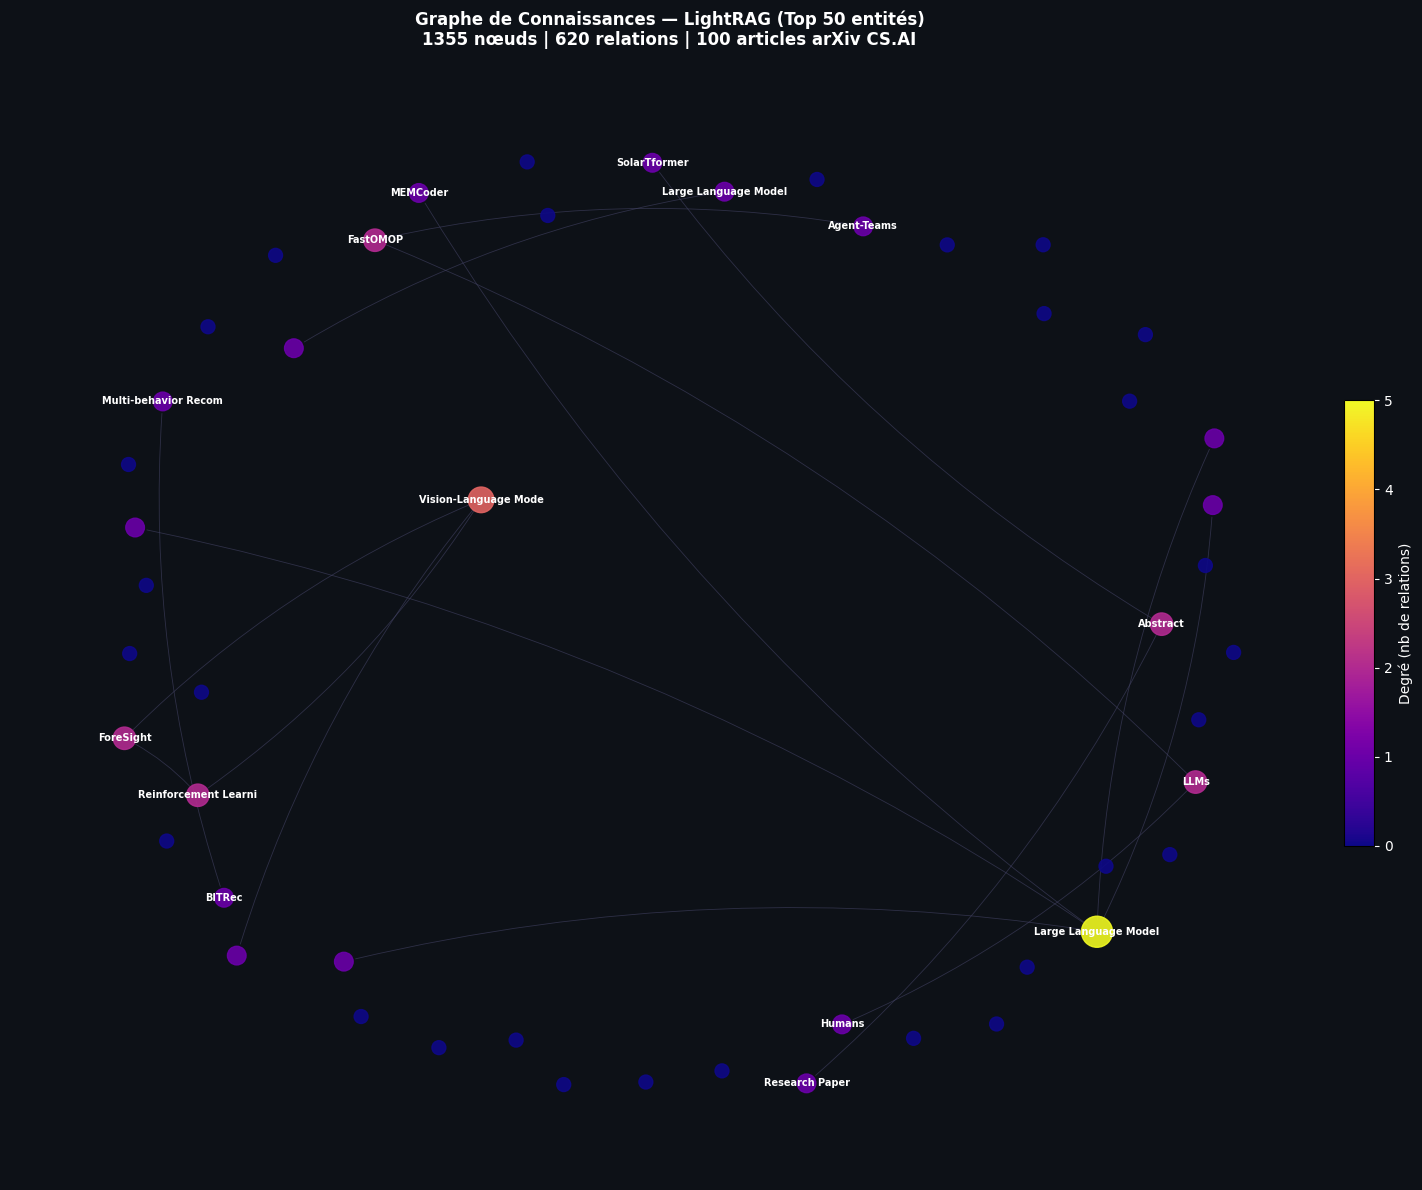

 Figure 8 sauvegardée : fig8_knowledge_graph.png


In [14]:
# ANALYSE DU GRAPHE NEO4J
# Statistiques + visualisation de la structure du graphe

import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

if not GRAPHML_PATH.exists():
    print(' Graphe non trouvé — lancer d\'abord l\'indexation')
else:
    graph = nx.read_graphml(str(GRAPHML_PATH))

    print(' ANALYSE DU GRAPHE LIGHTRAG')
    print(f'  Nœuds (entités)    : {graph.number_of_nodes()}')
    print(f'  Arêtes (relations) : {graph.number_of_edges()}')

    # Degré moyen
    degrees = [d for _, d in graph.degree()]
    print(f'  Degré moyen        : {np.mean(degrees):.2f}')
    print(f'  Degré max          : {max(degrees)}')
    print(f'  Densité du graphe  : {nx.density(graph):.4f}')

    # Top 10 nœuds les plus connectés (hubs)
    top_nodes = sorted(graph.degree(), key=lambda x: x[1], reverse=True)[:10]
    print(f'\n  Top 10 entités les plus connectées (hubs) :')
    for node, deg in top_nodes:
        name = graph.nodes[node].get('name', node)[:50]
        print(f'    [{deg:>3} relations] {name}')

    # Visualisation du sous-graphe 
    print('\n Génération de la visualisation du graphe...')

    # Sous-graphe : top 50 nœuds les plus connectés
    top_50_nodes = [n for n, _ in sorted(graph.degree(),
                    key=lambda x: x[1], reverse=True)[:50]]
    subgraph = graph.subgraph(top_50_nodes)

    fig, ax = plt.subplots(figsize=(16, 12))
    fig.patch.set_facecolor('#0D1117')
    ax.set_facecolor('#0D1117')

    # Layout spring (force-directed)
    pos = nx.spring_layout(subgraph, k=2.5, iterations=50, seed=42)

    # Taille des nœuds proportionnelle au degré
    node_sizes = [subgraph.degree(n) * 80 + 100 for n in subgraph.nodes()]

    # Couleur des nœuds par degré
    node_degrees = [subgraph.degree(n) for n in subgraph.nodes()]
    node_colors = [cm.plasma(d / max(node_degrees)) for d in node_degrees]

    # Dessiner les arêtes
    nx.draw_networkx_edges(
        subgraph, pos, ax=ax,
        edge_color='#444466', width=0.6, alpha=0.6,
        arrows=True, arrowsize=8,
        connectionstyle='arc3,rad=0.1'
    )

    # Dessiner les nœuds
    nx.draw_networkx_nodes(
        subgraph, pos, ax=ax,
        node_size=node_sizes,
        node_color=node_colors,
        alpha=0.9
    )

    # Labels des 15 nœuds les plus connectés
    top_15 = [n for n, _ in sorted(subgraph.degree(),
               key=lambda x: x[1], reverse=True)[:15]]
    labels = {
        n: subgraph.nodes[n].get('name', n)[:20]
        for n in top_15
    }
    nx.draw_networkx_labels(
        subgraph, pos, labels=labels, ax=ax,
        font_size=7, font_color='white', font_weight='bold'
    )

    ax.set_title(
        f'Graphe de Connaissances — LightRAG (Top 50 entités)\n'
        f'{graph.number_of_nodes()} nœuds | {graph.number_of_edges()} relations | '
        f'100 articles arXiv CS.AI',
        fontsize=12, fontweight='bold', color='white', pad=15
    )
    ax.axis('off')

    # Légende
    sm = plt.cm.ScalarMappable(cmap=cm.plasma,
                                norm=plt.Normalize(vmin=0, vmax=max(node_degrees)))
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, shrink=0.4, aspect=15, pad=0.01)
    cbar.set_label('Degré (nb de relations)', color='white', fontsize=10)
    cbar.ax.yaxis.set_tick_params(color='white')
    plt.setp(cbar.ax.yaxis.get_ticklabels(), color='white')

    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'fig8_knowledge_graph.png',
                dpi=150, bbox_inches='tight', facecolor='#0D1117')
    plt.show()
    print(' Figure 8 sauvegardée : fig8_knowledge_graph.png')

## 10 — Récapitulatif final Sprint 1

In [15]:
# RÉCAPITULATIF FINAL — SPRINT 1 COMPLET

from pathlib import Path
import json

print('  RÉCAPITULATIF — SPRINT 1 COMPLET')
print('  Wiame Anejjar | Master SDIA | Agentic GraphRAG')

# Vérification de tous les livrables
livrables = [
    # Données
    ('data/raw/arxiv_500.json',           'Corpus arXiv (500 abstracts)'),
    ('data/raw/hotpotqa_validation.json', 'Benchmark HotpotQA (7405 questions)'),
    ('data/raw/dataset_stats.json',       'Statistiques descriptives'),
    ('data/processed/arxiv_cleaned.json', 'Corpus nettoyé'),
    ('data/chunks/chunks_500.json',       'Chunks avec overlap'),
    ('data/processed/checkpoint.json',    'Checkpoint indexation'),
    ('data/processed/comparison_naive_hybrid.json', 'Résultats naive vs hybrid'),
    # Figures
    ('figures/fig1_distribution_tokens.png', 'Figure 1 — Tokens'),
    ('figures/fig2_distribution_themes.png', 'Figure 2 — Thèmes'),
    ('figures/fig3_hotpotqa_analyse.png',    'Figure 3 — HotpotQA'),
    ('figures/fig4_dashboard_complet.png',   'Figure 4 — Dashboard'),
    ('figures/fig5_wordcloud.png',           'Figure 5 — Nuage de mots'),
    ('figures/fig6_chunking_results.png',    'Figure 6 — Chunking'),
    ('figures/fig7_naive_vs_hybrid.png',     'Figure 7 — Naive vs Hybrid'),
    ('figures/fig8_knowledge_graph.png',     'Figure 8 — Graphe de connaissances'),
    # Fichiers projet
    ('JOURNAL.md',        'Journal de bord '),
    ('.gitignore',         '.gitignore'),
    ('requirements.txt',   'requirements.txt'),
]

print('\n Vérification des livrables :')
ok_count = 0
for filepath, description in livrables:
    p = Path(filepath)
    if p.exists():
        size = p.stat().st_size
        if size > 1024*1024:
            size_str = f'{size/1024/1024:.1f} Mo'
        elif size > 1024:
            size_str = f'{size/1024:.1f} Ko'
        else:
            size_str = f'{size} o'
        print(f'   {description:<45} ({size_str})')
        ok_count += 1
    else:
        print(f'   MANQUANT : {description}')

# Statistiques finales
print(f'\n Résultats Sprint 1 :')
print(f'  Livrables OK          : {ok_count}/{len(livrables)}')

# Charger les stats
try:
    with open('data/raw/dataset_stats.json') as f:
        s = json.load(f)
    print(f'  Articles arXiv        : {s["arxiv"]["nb_documents"]}')
    print(f'  Questions HotpotQA    : {s["hotpotqa"]["nb_questions"]:,}')
    print(f'  Chunks créés          : {s["chunking"]["total_chunks"]:,}')
    print(f'  Tokens/chunk (moy.)   : {s["chunking"]["tokens_per_chunk_mean"]:.0f}')
except:
    pass

# Lire le graphe si disponible
graphml = Path('indexes/lightrag/graph_chunk_entity_relation.graphml')
if graphml.exists():
    import networkx as nx
    g = nx.read_graphml(str(graphml))
    print(f'  Nœuds dans le graphe  : {g.number_of_nodes()}')
    print(f'  Relations dans graphe : {g.number_of_edges()}')

print(f'\n Prochaines étapes — Sprint 2 :')
print('  1. Indexer les 500 documents complets')
print('  2. Extraction NER/RE avec spaCy')
print('  3. Requêtes Cypher avancées dans Neo4j')
print('  4. Baseline RAG vectoriel (ChromaDB + RAGAS)')

print(f'\n SPRINT 1 TERMINÉ AVEC SUCCÈS !')


  RÉCAPITULATIF — SPRINT 1 COMPLET
  Wiame Anejjar | Master SDIA | Agentic GraphRAG

 Vérification des livrables :
   Corpus arXiv (500 abstracts)                  (1.6 Mo)
   Benchmark HotpotQA (7405 questions)           (3.1 Mo)
   Statistiques descriptives                     (1.3 Ko)
   Corpus nettoyé                                (1.6 Mo)
   Chunks avec overlap                           (934.5 Ko)
   Checkpoint indexation                         (60 o)
   Résultats naive vs hybrid                     (16.5 Ko)
   Figure 1 — Tokens                             (84.1 Ko)
   Figure 2 — Thèmes                             (122.8 Ko)
   Figure 3 — HotpotQA                           (75.1 Ko)
   Figure 4 — Dashboard                          (149.4 Ko)
   Figure 5 — Nuage de mots                      (634.9 Ko)
   Figure 6 — Chunking                           (111.2 Ko)
   Figure 7 — Naive vs Hybrid                    (156.6 Ko)
   Figure 8 — Graphe de connaissances            (242.6 Ko)
